# Data wrangling (2)
En este sprint aprenderás a limpiar, transformar y visualizar datos para responder preguntas clave. Trabajarás con datos reales, descubrirás patrones y comunicarás tus hallazgos con gráficos claros y efectivos.

Al finalizar, podrás:

    - Identificar y trabajar con distintos tipos de datos.
    - Crear nuevas variables a partir de datos existentes.
    - Combinar y agrupar datos de diferentes fuentes.
    - Generar visualizaciones que cuenten una historia basada en datos.

Estas habilidades te prepararán para enfrentar proyectos analíticos del mundo real, donde convertirás datos en decisiones.

In [1]:
#mporta librerías y el csv
import pandas as pd
df= pd.read_csv('music_project_en.csv')

#Limpia los índices y muestra la información limpia
df.columns=[i.strip().lower().replace(' ', '_').replace('userid', 'user_id') for i in df.columns]
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65079 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  65079 non-null  object
 1   track    63736 non-null  object
 2   artist   57512 non-null  object
 3   genre    63881 non-null  object
 4   city     65079 non-null  object
 5   time     65079 non-null  object
 6   day      65079 non-null  object
dtypes: object(7)
memory usage: 3.5+ MB


Index(['user_id', 'track', 'artist', 'genre', 'city', 'time', 'day'], dtype='object')

# Corregir errores de tipo con `astype()` y `to_numeric()`.

## Convertir a un tipo de datos específico con astype()

El método `astype()` de pandas te permite convertir tipos de datos.

Al igual que con otros métodos de pandas, existe para DataFrames y Series.

Al usarlo, debes especificar entre paréntesis el tipo de datos al cual deseas convertirlo. Por ejemplo, `df['column'] = df['column'].astype('int')` convertiría la columna `'column'` al tipo de datos entero.

### Convertir la columna `StockCode` a entero:

In [15]:
import pandas as pd

data = {
    'StockCode': ['10001', '10002', '10003', '10004', '10005', '10006'],
    'Description': ['Mug', 'T-shirt', 'Notebook', 'Invalid Code', 'Float code', 'Pen'],
    'Quantity': [10, 5, 8, 1, 3, 6],
    'UnitPrice': [2.5, 15.0, 4.2, 1.0, 6.75, 1.5]
}
df=pd.DataFrame(data)

#1. Convierte 'StockCode' a tipo de dato entero 'int'
df['StockCode'] = df['StockCode'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   StockCode    6 non-null      int64  
 1   Description  6 non-null      object 
 2   Quantity     6 non-null      int64  
 3   UnitPrice    6 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 324.0+ bytes


- convertir el string '1.0' -> flotante si se puede.
- convertir el string '1' -> entero si se puede.
- convertir el string '1.0' (en formato de flotante) -> entero no se puede.

## Convertir Strings a entero con el metodo `to_numeric`
Cuando intentas convertir strings a números, el método astype() solo funciona si todos los valores son válidos y perfectamente formateados. 

Aquí es donde to_numeric() se vuelve útil. A diferencia de astype(), el método to_numeric() si hace dichas conversiones:

In [16]:
import pandas as pd

d = {'col1': ['1.0', '2.0'], 'col2': ['3', '4']}
df = pd.DataFrame(data=d)

df['col1'] = pd.to_numeric(df['col1'])
print(df.dtypes)

col1    float64
col2     object
dtype: object


No obstante, de forma predeterminada, `to_numeric()` no puede convertir strings con caracteres no numéricos o decimales en números. Pero para eso esta el parametro `errors=`.

El parámetro errors= te permite decidir qué hacer si pandas encuentra un valor que no puede convertir:

* errors='raise' (por defecto): se detiene y lanza un error (igual que astype()).
* errors='coerce': reemplaza los valores no numéricos con NaN (muy útil para limpieza de datos).
* errors='ignore': deja los valores originales sin intentar convertirlos.

Ahora probemos convertir una columna con un valor no numerico, por ejemplo B.0, a entero.

Para eso, vamos a añadir el parametro errors='coerce' el cual remplazará el valor no valido  por NaN. 

In [17]:
import pandas as pd

d = {'col1': ['1.0', 'B.0'], 'col2': ['3', '4']}
df = pd.DataFrame(data=d)

df['col2'] = df['col2'].astype('int')
df['col1'] = pd.to_numeric(df['col1'], errors='coerce')

print(df.dtypes)
print(df)

col1    float64
col2      int64
dtype: object
   col1  col2
0   1.0     3
1   NaN     4


## Numpy arrays
Es importante verificar si existen valores con decimales. Aunque en la mayoría mayoría de los casos, esperas cantidades enteras, como 2 camisetas o 12 tazas. talvez existan valores como 0.5 kilos o 0.25 metros de listón. Si hay alguno de estos, podrías perder información importante al convertir.

¿Pero cómo saber si todos los valores de esta columna son enteros, aunque el tipo de datos sea float?

Aquí es donde entra `np.array_equal()`
## numpy.array_equal(array1, array2)
**¿Qué es un array?**

Un array (o arreglo) en NumPy es como una lista de Python

**¿Qué resultado arroja?**

Devuelve True si todos los elementos de ambos arrays son iguales y en el mismo orden. Si hay al menos un número diferente, devuelve False.

Para ilustrar esto, mira el siguiente ejemplo donde revisamos si al convertir los valores de la primera columna a enteros resultan los mismos valores:

In [19]:
import numpy as np
import pandas as pd

d = {'col1': [1.0, 2.0, 3.0, 4.0], 'col2': [5.0, 6.01, 7.0, 8.0]}
df = pd.DataFrame(data=d)

# comprueba si es seguro convertir 'col1' con np.array_equal
print(np.array_equal(df['col1'], df['col1'].astype('int')))
print(np.array_equal(df['col2'], df['col2'].astype('int')))

True
False


# Trabajar con fechas y horas
Excel a veces puede adivinar el formato correcto, pero no siempre lo logra.
Imagina abrir un archivo que mezcla formatos como 2019-08-03Z17:25:00 y 03, Aug 19, 5:25 PM. Incluso Excel se confundiría.

Por eso, si necesitas asegurarte de que las fechas están bien interpretadas y listas para hacer análisis con ellas, lo mejor es convertirlas al formato datetime de Python usando pandas.
URL PARA LISTA DE FORMATO: https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior

## ¿Cómo convertimos una fecha string a datetime?

Usamos el método `to_datetime()` de pandas. Este método transforma textos con formato de fecha como (`'2010-12-17T12:38:00Z'`) en objetos datetime que pandas puede entender.

Veamos un ejemplo sencillo:

In [20]:
string_date = '2010-12-17T12:38:00Z'
datetime_date = pd.to_datetime(string_date, format='%Y-%m-%dT%H:%M:%SZ')

print(type(string_date))      # <class 'str'>
print(type(datetime_date))    # <class 'Timestamp'>
print(datetime_date)          # 2010-12-17 12:38:00

<class 'str'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
2010-12-17 12:38:00


Ahora, esa fecha ya no es un simple texto: es un objeto datetime.
Esto nos permite hacer cosas como:

- Extraer solo la hora o el día.
- Calcular cuántos minutos pasaron entre dos eventos.
- Agrupar ventas por semana, mes o trimestre.

### Ejercicio. 
Convierte la columna `time` a formato datetime

In [2]:
import pandas as pd
df= pd.read_csv('music_project_en.csv')

#Limpia los índices y muestra la información limpia
df.columns=[i.strip().lower().replace(' ', '_').replace('userid', 'user_id') for i in df.columns]
print(df.head())
#aquí está la conversión
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df.info()

    user_id                        track            artist  genre  \
0  FFB692EC            Kamigata To Boots  The Mass Missile   rock   
1  55204538  Delayed Because of Accident  Andreas Rönnberg   rock   
2    20EC38            Funiculì funiculà       Mario Lanza    pop   
3  A3DD03C9        Dragons in the Sunset        Fire + Ice   folk   
4  E2DC1FAE                  Soul People        Space Echo  dance   

          city      time        day  
0  Shelbyville  20:28:33  Wednesday  
1  Springfield  14:07:09     Friday  
2  Shelbyville  20:58:07  Wednesday  
3  Shelbyville  08:37:09     Monday  
4  Springfield  08:34:34     Monday  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65079 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   user_id  65079 non-null  object        
 1   track    63736 non-null  object        
 2   artist   57512 non-null  object        
 3   genre    63881 non-

## Trabajar con atributos datetime y zonas horarias
En esta clase aprenderás a extraer partes útiles de una fecha, como el día del mes o el nombre del día, utilizando .dt. También aprenderás a cambiar la zona horaria de tu dataset para que los datos reflejen correctamente el lugar donde ocurrieron los eventos. Estas habilidades son clave para analizar comportamientos por día y comparar información entre distintas regiones.
## Extraer información útil de fechas con .dt en pandas
**¿Por qué querríamos extraer partes de una fecha?**

Imagina que te han pedido preparar un reporte par saber cuáles son los días más activos en ventas cada mes, por ejemplo a principios de mes e.g el 2 de cada mes o despues de pagar quincenas e.g. el 16. Para descubrirlo, necesitas descomponer las fechas completas en partes como el día, el mes, o incluso la hora.

Pandas nos permite hacerlo fácilmente... si sabemos cómo.

Pandas te permite acceder a muchos otros atributos de las fechas usando .dt, como:
* `.dt.year` → año
* `.dt.month` → mes
* `.dt.day` → día
* `.dt.hour` → hora
* `.dt.minute` → minuto
* `.dt.weekday` → día de la semana (0 = lunes, 6 = domingo)
* `.dt.date` → solo la fecha, sin la hora

Puedes ver más opciones en la documentación oficial: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#time-date-components

### Ejercicio
Crea una nueva columna que muestre solo la hora de reproducción de cada canción, llámala `'la_hora'`

Muestra las columnas `'track'`, `'time'` y `'la_hora'` de las primeras 5 filas

In [3]:
#print(df.head())
df['la_hora'] = df['time'].dt.hour
print(df[['track', 'time', 'la_hora']].head())

                         track                time  la_hora
0            Kamigata To Boots 1900-01-01 20:28:33       20
1  Delayed Because of Accident 1900-01-01 14:07:09       14
2            Funiculì funiculà 1900-01-01 20:58:07       20
3        Dragons in the Sunset 1900-01-01 08:37:09        8
4                  Soul People 1900-01-01 08:34:34        8


## Trabajar con husos horarios
Es muy común encontrarte con datos que vienen de distintos países, donde cada sistema registra la hora en su zona horaria local. También puede que tus registros estén en UTC, pero debas mostrar resultados en la zona horaria, donde sucedieron los eventos.
Para convertir datos de un huso horario a otro, pandas ofrece dos herramientas poderosas:
* `.dt.tz_localize()` — asigna una zona horaria a una columna de tipo datetime.
* `.dt.tz_convert()` — convierte una columna con zona horaria a otra zona horaria diferente.

Es decir  `.dt.tz_localize()`  te permite asignar una zona horaria a una columna datetime para que tus datos "tengan conocimiento" de su zona horaria. `.dt.tz_convert()` te permite convertir una columna "con conocimiento de su zona horaria" en una zona horaria distinta.
Paso 1: Asignar una zona horaria

Supongamos que la columna `'InvoiceDate'` de tu tienda online está en formato UTC. Vamos a especificarlo con `.tz_localize()`:
Puedes consultar esta lista en Wikipedia para ver todas las zonas horarias que puedes usar con pandas.
https://en.wikipedia.org/wiki/List_of_tz_database_time_zones#List

# Ingeniería de características
En este capítulo, volverás al dataset de ventas de videojuegos que viste antes en el sprint. Utilizando este dataset, aprenderás:
- Varias formas de crear nuevas columnas a partir de los datos existentes.
- Como escribir tus propias funciones.
- Como usar el método apply() para crear columnas nuevas con base en criterios complejos de procesamiento que no se pueden cumplir con las funciones existentes de pandas.

## Ejercicios



In [ ]:
import pandas as pd
df= pd.read_csv('music_project_en.csv')

#Limpia los índices y muestra la información limpia
df.columns=[i.strip().lower().replace(' ', '_').replace('userid', 'user_id') for i in df.columns]

In [1]:
import pandas as pd
import random

# Listas de valores para generar datos
nombres_juegos = ['Juego ', 'Game B', 'Game C', 'Adventure Quest', 'Racing Pro', 'Sports Master']
plataformas = ['PS4', 'Xbox', 'PC', 'Switch', 'Mobile', '3DS', 'PSP', 'DS', 'GB', 'GBA']
generos = ['Action', 'Sports', 'Racing', 'Adventure', 'Strategy', 'Platform', 'Metroidvania']
publishers = ['Sony', 'Microsoft', 'Nintendo', 'EA', 'Activision']
developers = ['Sony', 'Microsoft', 'Nintendo', 'EA', 'Activision', 'Ubisoft', 'Square Enix', 'Capcom', 'Naughty Dog', 'Rockstar Games', 'FromSoftware', 'Bungie']

# Generar 100 registros
data = []
for i in range(100):
    registro = {
        'name': f"{random.choice(nombres_juegos)} {i+1}",
        'platform': random.choice(plataformas),
        'year_of_release' : random.randint(1980, 2020),
        'genre': random.choice(generos),
        'publisher': random.choice(publishers),
        'developer' : random.choice(developers),
        'na_sales': round(random.uniform(0.1, 50.0), 2),
        'eu_sales': round(random.uniform(0.1, 30.0), 2),
        'jp_sales': round(random.uniform(0.1, 20.0), 2),
        'critic_score': round(random.uniform(0.1, 100.0),2),
        'public_score' : round(random.uniform(0.1, 10.0),2)
    }
    data.append(registro)


df_gms = pd.DataFrame(data)

### Añade la columna `total_sales` al DataFrame de videokuegos sumando `na_sales`, `jp_sales`, `eu_sales`

In [17]:
df_gms['total_sales'] = df_gms['na_sales'] + df_gms['jp_sales'] + df_gms['eu_sales']
print(df_gms.head())

           name platform  year_of_release         genre publisher  \
0  Racing Pro 1       GB             2018        Action      Sony   
1  Racing Pro 2       DS             1992      Platform  Nintendo   
2      Game B 3       DS             1991  Metroidvania      Sony   
3      Juego  4      GBA             1998     Adventure        EA   
4      Game B 5   Mobile             1985  Metroidvania        EA   

        developer  na_sales  eu_sales  jp_sales  critic_score  public_score  \
0            Sony     13.52     23.00      8.94         82.88          0.36   
1  Rockstar Games     36.93      4.86      4.01          8.17          3.10   
2     Square Enix      0.88      5.07      7.52          6.37          5.22   
3          Bungie      6.23      3.53      6.47         37.51          9.88   
4    FromSoftware      1.98     18.92      4.29          9.13          2.90   

   total_sales  
0        45.46  
1        45.80  
2        13.47  
3        16.23  
4        25.19  


Te han encargado comprobar cuál es el juego más vendido (en promedio) en todos los mercados.

Necesitas:
* Tomar el promedio de las columnas 'jp_sales', 'na_sales' y 'eu_sales' y guardarlo en una nueva columna llamada 'average_sales'.
* Ordenar los valores del DataFrame por average_sales en orden descendente. Utiliza el método sort_values, pasando los argumentos correctos a los parámetros by= y ascending=.
* Después muestra los primeros cinco valores del dataframe con la nueva columna.

In [18]:
## Añade la columna de ventas promedio
df_gms['average_sales'] = df_gms['total_sales'] /3
# Imprime la columna promedio
print(df_gms.head())
df_gms = df_gms.sort_values(by = 'average_sales', ascending=False)
print(df_gms.head())

           name platform  year_of_release         genre publisher  \
0  Racing Pro 1       GB             2018        Action      Sony   
1  Racing Pro 2       DS             1992      Platform  Nintendo   
2      Game B 3       DS             1991  Metroidvania      Sony   
3      Juego  4      GBA             1998     Adventure        EA   
4      Game B 5   Mobile             1985  Metroidvania        EA   

        developer  na_sales  eu_sales  jp_sales  critic_score  public_score  \
0            Sony     13.52     23.00      8.94         82.88          0.36   
1  Rockstar Games     36.93      4.86      4.01          8.17          3.10   
2     Square Enix      0.88      5.07      7.52          6.37          5.22   
3          Bungie      6.23      3.53      6.47         37.51          9.88   
4    FromSoftware      1.98     18.92      4.29          9.13          2.90   

   total_sales  average_sales  
0        45.46      15.153333  
1        45.80      15.266667  
2        13.47

In [23]:
print(df_gms['year_of_release'].min(), df_gms['year_of_release'].max())
# Crea un series con los años como índices y la cantidad de lanzamientos como columna
df_year_of_release = df_gms['year_of_release'].value_counts().sort_index()
# Acomoda los índices por año

print(df_year_of_release)


1980 2020
year_of_release
1980    1
1981    3
1982    1
1983    3
1984    4
1985    3
1986    2
1987    5
1988    1
1990    4
1991    6
1992    3
1993    2
1994    1
1996    3
1997    4
1998    3
1999    1
2000    3
2001    6
2003    1
2004    3
2005    1
2006    4
2007    2
2008    2
2009    5
2010    3
2011    2
2012    2
2013    2
2014    1
2015    1
2016    2
2017    2
2018    3
2019    2
2020    3
Name: count, dtype: int64


## Categorización
Necesitamos realizar la categorización, agrupando los datos en nuevas categorías que creamos. En este caso, vamos a agrupar los juegos en cuatro categorías en función de la época.
- Los lanzados antes del año 2000 irán en la categoría `'retro'`.
- Los lanzados entre el 2000 y el 2009 irán en 'modern' (moderno).
- Los lanzados a partir del 2010 irán en 'recent' (reciente).
- Los que no tienen año de lanzamiento irán en 'unknown' (desconocido).

Queremos colocar cada juego en una de estas cuatro categorías y almacenar el resultado en una nueva columna.

Para esto no hay ninguna función prefabricada de pandas. Por fortuna, podemos escribir nuestra propia función hecha a la medida de nuestras necesidades. La función debe aceptar el año de lanzamiento como input y devolver como resultado la categoría de época para ese año.

Así se verá nuestra función personalizada era_group():

In [25]:
import numpy as np
def era_group(year):
    """
    La función devuelve el grupo de época de los juegos de acuerdo con el año de lanzamiento usando estas reglas:
    —'retro'   para año < 2000
    —'modern'  para 2000 <= año < 2010
    —'recent'  para año >= 2010
    —'unknown' para buscar valores año (NaN)
    """

    if year < 2000:
        return 'retro'
    elif year < 2010:
        return 'modern'
    elif year >= 2010:
        return 'recent'
    else:
        return 'unknown'

#Checamos que funcione
print(era_group(1983))
print(era_group(2009))
print(era_group(2021))
print(era_group(np.nan))

retro
modern
recent
unknown


In [30]:
#Creamos la columna 'era_group'
df_gms['era_group'] = df_gms['year_of_release'].apply(era_group)
print(df_gms.head())
# Contamos cuántos valores para cada era de juego
print(df_gms['era_group'].value_counts())

                  name platform  year_of_release         genre publisher  \
68       Racing Pro 69      GBA             2007  Metroidvania  Nintendo   
49    Sports Master 50      PS4             2019        Sports      Sony   
88           Game B 89       PC             1984      Strategy      Sony   
91    Sports Master 92      PSP             2005     Adventure      Sony   
94  Adventure Quest 95      PS4             2011      Strategy  Nintendo   

         developer  na_sales  eu_sales  jp_sales  critic_score  public_score  \
68    FromSoftware     48.87     28.49     17.52         11.01          6.96   
49      Activision     49.34     29.01     12.76         92.32          9.32   
88         Ubisoft     48.44     15.78     19.77         59.03          1.50   
91     Naughty Dog     34.64     28.25     18.95          6.34          7.46   
94  Rockstar Games     44.27     21.81     15.11         26.32          8.94   

    total_sales  average_sales era_group  
68        94.88    

Ejercicio

Comienza por escribir una función llamada score_group() que organice los juegos por categorías de acuerdo con las puntuaciones de las críticas. Categoriza las puntuaciones con base en estas características:

    Devuelve 'low' (bajo) si el valor de score es menor a 60.
    Devuelve 'medium' (medio) si el valor de score está entre 60 y 79 inclusive.
    Devuelve 'high' (alto) si el valor de score es 80 o mayor.
    Devuelve 'no score' (sin puntuación) en cualquier otro caso (por ejemplo, si score no contiene un valor numérico válido o está ausente).

La función score_group() debe tener un input numérico llamado score. La salida debe ser una cadena que designe la categoría de la puntuación.

Asegúrate de que tu función produzca el output correcto cuando se le pasen los valores 10, 65, 99 y np.nan. Escribimos una declaración print() distinta para llamar a cada función.

No dudes en copiar nuestra función del ejemplo anterior y adaptarla a tus necesidades actuales.

In [7]:
# Definimos función para categorización
import numpy as np
def score_group(score):

    """
    La función devuelve el grupo de score en el que están los juegos de acuerdo con el score de la crítica usando estas reglas:
    —'low'   para score < 60
    —'medium'  para 60 <= score < 80
    —'high'  para score >= 80
    —'unknown' para buscar valores año (NaN)
    """

    if score < 60:
        return 'low'
    elif score < 80:
        return 'medium'
    elif score >= 80:
        return 'high'
    else:
        return 'no score'
# imprime los resultados de llamar a la función con estos inputs en orden: 10, 65, 99, np.nan
print(score_group(10))
print(score_group(65))
print(score_group(99))
print(score_group(np.nan))

low
medium
high
no score


Dos 2.

Agrega una columna 'score_categorized' a la tabla df aplicando la función score_group() a la columna 'critic_score', con el método apply(). Imprime las primeras 5 filas para asegurarte de que se creó la nueva columna correctamente.

In [8]:
df_gms['score_categorized']=df_gms['critic_score'].apply(score_group)
print(df_gms.head())

              name platform  year_of_release         genre   publisher  \
0         Game C 1      GBA             1987        Action        Sony   
1         Game C 2   Mobile             2004     Adventure  Activision   
2         Juego  3       GB             2009        Sports        Sony   
3  Sports Master 4      3DS             1984      Platform   Microsoft   
4         Game C 5       DS             1984  Metroidvania   Microsoft   

        developer  na_sales  eu_sales  jp_sales  critic_score  public_score  \
0        Nintendo     11.73      2.18     14.36         45.90          0.14   
1     Naughty Dog      7.92      9.90     12.63         29.40          6.76   
2            Sony     36.28     20.68     13.77         95.10          4.32   
3  Rockstar Games     36.66     23.20      4.01         36.87          8.94   
4            Sony     27.08      0.24      8.45         50.02          3.11   

  score_categorized  
0               low  
1               low  
2             

Tres 3.

Ahora calcula el total de ventas de Norteamérica para cada categoría de critic score (puntuación de crítica).

Para hacerlo, es necesario:

    Agrupar por la nueva columna 'score_categorized' utilizando el método groupby().
    Calcular la suma de la columna 'na_sales' del DataFrame agrupado utilizando sum().
    Mostrar el resultado.

In [ ]:
df['score_categorized'] = df['critic_score'].apply(score_group)

df_grouped = df.groupby('score_categorized')
# escribe tu código aquí
df_sum = df_grouped['na_sales'].sum() 
# escribe tu código aquí

print(df_sum)


In [32]:
df_gms.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 68 to 22
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             100 non-null    object 
 1   platform         100 non-null    object 
 2   year_of_release  100 non-null    int64  
 3   genre            100 non-null    object 
 4   publisher        100 non-null    object 
 5   developer        100 non-null    object 
 6   na_sales         100 non-null    float64
 7   eu_sales         100 non-null    float64
 8   jp_sales         100 non-null    float64
 9   critic_score     100 non-null    float64
 10  public_score     100 non-null    float64
 11  total_sales      100 non-null    float64
 12  average_sales    100 non-null    float64
 13  era_group        100 non-null    object 
dtypes: float64(7), int64(1), object(6)
memory usage: 11.7+ KB


In [34]:
def era_sales_group(row):
    """
    La función devuelve una categoría de juegos según el año de lanzamiento y las ventas totales mediante las siguientes reglas:
    —'retro'   para año < 2000 y las ventas totales < $1 million
    —'modern'  para 2000 <= año < 2010 y las ventas totales < $1 million
    —'recent'  para año >= 2010 y las ventas totales < $1 million
    —'classic' para año < 2010 y las ventas totales >= $1 million
    —'big hit' para año >= 2010 y las ventas totales >= $1 million
    """

    year = row['year_of_release']
    na_sales = row['na_sales']
    eu_sales = row['eu_sales']
    jp_sales = row['jp_sales']
    
    total_sales = na_sales + eu_sales + jp_sales
    
    if year < 2000:
        if total_sales < 1:
            return 'retro'
        else:
            return 'classic'
    if year < 2010:
        if total_sales < 1:
            return 'modern'
        else:
            return 'classic'
    if year >= 2010:
        if total_sales < 1:
            return 'recent'
        else:
            return 'big hit'

row = df_gms.iloc[0] # usa la primera fila como input de ejemplo

print(row)
print()
print('Este juego es', era_sales_group(row))

name               Racing Pro 69
platform                     GBA
year_of_release             2007
genre               Metroidvania
publisher               Nintendo
developer           FromSoftware
na_sales                   48.87
eu_sales                   28.49
jp_sales                   17.52
critic_score               11.01
public_score                6.96
total_sales                94.88
average_sales          31.626667
era_group                 modern
Name: 68, dtype: object

Este juego es classic


## Ahora, vamos a escribir una función llamada era_sales_group() que coloque los juegos en las siguientes categorías según el año de lanzamiento y las ventas totales:

    Los que se lanzaron antes del 2000 y que tienen menos de $1 millón en ventas irán a la categoría 'retro'.
    Los que se lanzaron entre el 2000 y el 2009 (inclusive) con menos de $1 millón de ventas irán a la categoría 'modern'.
    Los que se lanzaron antes del 2010 y que tienen $1 millón o más en ventas irán a la categoría 'classic'.
    Los que se lanzaron a partir del 2010 y que tienen menos de $1 millón en ventas irán a la categoría 'recent'.
    Los que se lanzaron a partir del 2010 y que tienen $1 millón o más en ventas irán a la categoría 'big hit'.

Así es como se verá la función junto con el output de muestra:

In [2]:
def era_sales_group(row):
    """
    La función devuelve una categoría de juegos según el año de lanzamiento y las ventas totales mediante las siguientes reglas:
    —'retro'   para año < 2000 y las ventas totales < $1 million
    —'modern'  para 2000 <= año < 2010 y las ventas totales < $1 million
    —'recent'  para año >= 2010 y las ventas totales < $1 million
    —'classic' para año < 2010 y las ventas totales >= $1 million
    —'big hit' para año >= 2010 y las ventas totales >= $1 million
    """

    year = row['year_of_release']
    na_sales = row['na_sales']
    eu_sales = row['eu_sales']
    jp_sales = row['jp_sales']
    
    total_sales = na_sales + eu_sales + jp_sales
    
    if year < 2000:
        if total_sales < 1:
            return 'retro'
        else:
            return 'classic'
    if year < 2010:
        if total_sales < 1:
            return 'modern'
        else:
            return 'classic'
    if year >= 2010:
        if total_sales < 1:
            return 'recent'
        else:
            return 'big hit'

row = df_gms.iloc[0] # usa la primera fila como input de ejemplo

print(row)
print()
print('Este juego es', era_sales_group(row))

name               Game C 1
platform                GBA
year_of_release        1987
genre                Action
publisher              Sony
developer          Nintendo
na_sales              11.73
eu_sales               2.18
jp_sales              14.36
critic_score           45.9
public_score           0.14
Name: 0, dtype: object

Este juego es classic


Al igual que la función era_group() de la lección pasada, era_sales_group() tiene un parámetro: row. Sin embargo, en este caso se espera que row sea una sola fila entera del DataFrame.

Esta función requiere cuatro valores de la fila para hacer la categorización: uno para el año de lanzamiento y tres para calcular las ventas totales. Observa que la función usa nombres de columnas de df para extraer estos valores, así que no funcionará en otro DataFrame con columnas diferentes, sino que depende de los datos en vg_sales.csv.

Usamos df.iloc[0] para tomar la primera fila de df con el objetivo de probar nuestra función, lo que produjo el output 'classic'. Si revisamos las reglas de categorización, esto tiene sentido. Wii Sports fue lanzado antes del 2010 y ciertamente alcanzó más de $1 millón, ¡incluso mucho más!

### Probar la función con filas personalizadas

Hemos probado era_sales_group() para el caso de 'classic', ¿pero qué pasa con las otras cuatro categorías? Sería una tarea tediosa buscar en los datos las filas correspondientes a cada caso. Afortunadamente, podemos crear nuestras propias filas con los valores que queramos al convertir una lista de nombres de columna y una lista de valores de fila en un objeto tipo Series:

In [3]:
cols = ['year_of_release', 'na_sales', 'eu_sales', 'jp_sales']

row_1 = pd.Series([1989, 0, 0, 0.6], index=cols) # expect 'retro'
row_2 = pd.Series([1989, 1, 2, 0], index=cols)   # expect 'classic'
row_3 = pd.Series([2006, 0.3, 0, 0], index=cols) # expect 'modern'
row_4 = pd.Series([2020, 0, 0.4, 0], index=cols) # expect 'recent'
row_5 = pd.Series([2020, 1, 1, 1], index=cols)   # expect 'big hit'

print(row_1, row_2, row_3, row_4, row_5, sep='\n\n')
print()

rows = [row_1, row_2, row_3, row_4, row_5]

for row in rows:
    print('Este juego es', era_sales_group(row))

year_of_release    1989.0
na_sales              0.0
eu_sales              0.0
jp_sales              0.6
dtype: float64

year_of_release    1989
na_sales              1
eu_sales              2
jp_sales              0
dtype: int64

year_of_release    2006.0
na_sales              0.3
eu_sales              0.0
jp_sales              0.0
dtype: float64

year_of_release    2020.0
na_sales              0.0
eu_sales              0.4
jp_sales              0.0
dtype: float64

year_of_release    2020
na_sales              1
eu_sales              1
jp_sales              1
dtype: int64

Este juego es retro
Este juego es classic
Este juego es modern
Este juego es recent
Este juego es big hit


## Crear una columna

Ahora que has comprendido mejor cómo trabajan las funciones, vamos a aprender a usarlas junto con apply() para crear nuevas columnas.

En este caso, queremos crear una columna llamada 'game_category' que categorice cada juego según el output de nuestra función era_sales_group(). Al igual que en la lección anterior, llamaremos al método apply(). No obstante, esta vez hay dos diferencias importantes:

- El método apply() se llama en el DataFrame df entero en vez de en una sola columna.
- Necesitamos usar el parámetro axis= al llamar al método apply().

De forma predeterminada, el parámetro axis= está en 0, lo que significa que apply() le pasa valores de columna a la función que se usa como input. En cambio, si queremos que apply() pase los valores de fila de la función, necesitamos configurar axis=1.

Entonces, se puede crear la nueva columna 'game_category' así:

In [9]:
def era_sales_group(row):
    """
    La función devuelve una categoría de juegos según el año de lanzamiento y las ventas totales mediante las siguientes reglas:
    —'retro'   para año < 2000 y las ventas totales < $1 million
    —'modern'  para 2000 <= año < 2010 y las ventas totales < $1 million
    —'recent'  para año >= 2010 y las ventas totales < $1 million
    —'classic' para año < 2010 y las ventas totales >= $1 million
    —'big hit' para año >= 2010 y las ventas totales >= $1 million
    """

    year = row['year_of_release']
    na_sales = row['na_sales']
    eu_sales = row['eu_sales']
    jp_sales = row['jp_sales']
    
    total_sales = na_sales + eu_sales + jp_sales
    
    if year < 2000:
        if total_sales < 1:
            return 'retro'
        else:
            return 'classic'
    if year < 2010:
        if total_sales < 1:
            return 'modern'
        else:
            return 'classic'
    if year >= 2010:
        if total_sales < 1:
            return 'recent'
        else:
            return 'big hit'

df_gms['game_category'] = df_gms.apply(era_sales_group, axis=1)
print(df_gms.sample(5, random_state=321))

                name platform  year_of_release      genre   publisher  \
86  Sports Master 87      PS4             1981  Adventure  Activision   
25     Racing Pro 26   Mobile             1998     Sports    Nintendo   
45  Sports Master 46     Xbox             2015     Racing  Activision   
32         Juego  33   Mobile             1995   Platform          EA   
20     Racing Pro 21      3DS             1998     Action    Nintendo   

      developer  na_sales  eu_sales  jp_sales  critic_score  public_score  \
86  Naughty Dog     29.67      7.27     17.54          2.51          9.95   
25           EA     21.84     24.99     19.60         55.16          4.15   
45   Activision     14.52      8.67     19.46          0.49          6.08   
32         Sony     21.12      0.74      1.96         52.59          2.11   
20           EA     45.42     23.11     10.81         91.99          4.22   

   score_categorized game_category  
86               low       classic  
25               low    

Ahora vemos que logramos crear la nueva columna y podemos comenzar el análisis. Por ejemplo, podemos recurrir al método value_counts() para obtener el número de juegos que pertenecen a cada categoría:

In [10]:
print(df_gms['game_category'].value_counts())

game_category
classic    74
big hit    26
Name: count, dtype: int64


###
Escribe una función que se llame avg_score_group() (grupo puntuación promedio) que tenga un parámetro llamado row. El parámetro row debe ser un objeto tipo Series de pandas. La función debe calcular la calificación promedio de cada juego, luego devolver una cadena que coloque cada uno en una de estas categorías:

    valor 'low' para promedios menores de 60.
    valor 'medium' para promedios de 60 a 79.
    valor 'high' (alto) para puntuaciones mayores a 80.

Para calcular la puntuación promedio, avg_score_group() debe tomar los valores de row con los nombres de columna 'critic_score' y 'user_score'. La fórmula para calcularlo es avg_score = (critic_score + user_score * 10) / 2.

Te dejamos las pruebas hechas, se debe imprimir low, medium y high, en ese orden.

In [12]:
def avg_score_group(row):
    critica = row['critic_score']
    usuario = row['user_score']
    promedio = (critica + usuario * 10)/2
    if promedio < 60:
        return 'low'
    elif promedio < 80:
        return 'medium'
    elif promedio >= 80:
        return 'high'



# parte de prueba a continuación, por favor no la cambies

col_names = ['critic_score', 'user_score']
test_low  = pd.Series([10, 1.0], index=col_names)
test_med  = pd.Series([65, 6.5], index=col_names)
test_high = pd.Series([99, 9.9], index=col_names)

rows = [test_low, test_med, test_high]

for row in rows:
    print(avg_score_group(row))


low
medium
high


### Ejercicio 2
Ahora es momento de poner a prueba tu nueva función. Crea tres filas personalizadas con estos nombres de variables y valores:

    row_1: puntuación de la crítica de 66 y puntuación de los usuarios de 3.6.
    row_2: puntuación de la crítica de 72 y puntuación de los usuarios de 8.1.
    row_3: puntuación de la crítica de 99 y puntuación de los usuarios de 9.4.

Cada una de las variables de fila debe ser un objeto tipo Series con valores de índice 'critic_score' y 'user_score' para que avg_score_group() pueda extraer los valores correctos.

El precódigo define la función avg_score_group() del ejercicio anterior, aunque puede que se vea distinta a tu solución. Tu tarea es imprimir el resultado de llamar a avg_score_group() con cada uno de los inputs especificados.

In [13]:
# crea las filas de input de prueba aquí
col_nms = ['critic_score', 'user_score']
row_1 = pd.Series([66,3.6], index=col_nms)
row_2 = pd.Series([72, 8.1], index=col_nms)
row_3 = pd.Series([99, 9.4], index=col_nms)

rows=[row_1, row_2, row_3]
for row in rows:
    print(avg_score_group(row), sep='\n')

low
medium
high


# Transformación de datos

## Itroducción
¡Te damos la bienvenida al capítulo sobre transformaciones de datos!

En este capítulo, estudiarás más a fondo la agrupación y combinación de datos procedentes de distintas fuentes. 

Concretamente, aprenderás:

    Cómo funciona la función groupby().
    Una nueva forma de agrupar datos mediante tablas dinámicas.
    A combinar datos de diferentes DataFrames mediante la concatenación y la fusión.

Seguiremos usando el conjunto de datos de ventas de videojuegos para ayudarte a aprender estas importantes técnicas de análisis de datos.

In [15]:
import pandas as pd
import numpy as np
import random

# Listas de valores para generar datos
nombres_juegos = ['Juego ', 'Game B', 'Game C', 'Adventure Quest', 'Racing Pro', 'Sports Master']
plataformas = ['PS4', 'Xbox', 'PC', 'Switch', 'Mobile', '3DS', 'PSP', 'DS', 'GB', 'GBA']
generos = ['Action', 'Sports', 'Racing', 'Adventure', 'Strategy', 'Platform', 'Metroidvania']
publishers = ['Sony', 'Microsoft', 'Nintendo', 'EA', 'Activision']
developers = ['Sony', 'Microsoft', 'Nintendo', 'EA', 'Activision', 'Ubisoft', 'Square Enix', 'Capcom', 'Naughty Dog', 'Rockstar Games', 'FromSoftware', 'Bungie']

# Generar 100 registros
data = []
for i in range(100):
    registro = {
        'name': f"{random.choice(nombres_juegos)} {i+1}",
        'platform': random.choice(plataformas),
        'year_of_release' : random.randint(1980, 2020),
        'genre': random.choice(generos),
        'publisher': random.choice(publishers),
        'developer' : random.choice(developers),
        'na_sales': round(random.uniform(0.1, 50.0), 2),
        'eu_sales': round(random.uniform(0.1, 30.0), 2),
        'jp_sales': round(random.uniform(0.1, 20.0), 2),
        'critic_score': round(random.uniform(0.1, 100.0),2),
        'user_score' : round(random.uniform(0.1, 10.0),2)
    }
    data.append(registro)


df = pd.DataFrame(data)

Digamos que necesitamos la puntuación promedio de la crítica para cada género:

In [16]:
mean_score = df.groupby('genre')['critic_score'].mean()
print(mean_score)

genre
Action          44.600000
Adventure       44.464167
Metroidvania    51.196364
Platform        36.510000
Racing          53.998500
Sports          47.234444
Strategy        45.849000
Name: critic_score, dtype: float64


Para agrupar por varias columnas, pasamos una lista al método groupby():

In [17]:
grp = df.groupby(['platform', 'genre'])
print(grp['critic_score'].mean())

platform  genre       
3DS       Action          10.135000
          Platform        22.400000
          Racing          77.946667
          Sports          85.540000
          Strategy        17.060000
DS        Adventure       17.040000
          Metroidvania    47.777500
          Racing          84.130000
GB        Adventure        9.460000
          Metroidvania    83.010000
          Racing          39.153333
          Sports          71.435000
          Strategy        64.436667
GBA       Action          53.925000
          Adventure       87.420000
          Metroidvania     3.760000
          Platform        10.535000
          Racing          23.370000
          Sports          34.290000
Mobile    Adventure       42.200000
          Platform        52.705000
          Racing          84.810000
          Sports          47.323333
          Strategy        12.100000
PC        Action          12.440000
          Adventure       32.390000
          Metroidvania    56.795000
     

Ahora tenemos la puntuación promedio de la crítica para cada género en cada plataforma. Como agrupamos por dos columnas, nuestro resultado es un objeto Series de múltiples índices con dos valores de índice para cada puntuación promedio, en este caso, 'platform' y 'genre'.

Aquí la variable grp es un objeto que contiene el DataFrame agrupado antes de que procesemos cada grupo con el método mean(). Se denomina objeto "en espera". Si intentamos imprimir el objeto grp, se mostrará una representación del objeto en forma de texto.

In [18]:
print(grp)

Cuando imprimimos df.groupby('column_name'), no vemos la impresión de una tabla como ocurriría si imprimiéramos df. En cambio, vemos el tipo de datos del objeto agrupado (DataFrameGroupBy) y una cadena (0x0000022EA82A75B0) que representa la ubicación en la memoria de la computadora donde se almacena el objeto. No se mostrará ningún resultado hasta que procesemos los grupos.

## Dividir-aplicar-combinar
El objeto DataFrameGroubBy forma parte de un framework de procesamiento de datos llamado dividir-aplicar-combinar:

    dividir los datos en grupos;
    aplicar una función de agregación estadística a cada grupo;
    combinar los resultados para cada grupo.

Dividimos los datos en grupos con df.groupby(['platform', 'genre']), aplicamos el método mean() y combinamos el resultado en un objeto Series grp['critic_score'].mean().

Por supuesto, podemos omitir la creación de los objetos grp y mean_scores y hacer que pandas realice los tres pasos con una sola línea de código:

In [19]:
print(df.groupby(['platform', 'genre'])['critic_score'].mean())

platform  genre       
3DS       Action          10.135000
          Platform        22.400000
          Racing          77.946667
          Sports          85.540000
          Strategy        17.060000
DS        Adventure       17.040000
          Metroidvania    47.777500
          Racing          84.130000
GB        Adventure        9.460000
          Metroidvania    83.010000
          Racing          39.153333
          Sports          71.435000
          Strategy        64.436667
GBA       Action          53.925000
          Adventure       87.420000
          Metroidvania     3.760000
          Platform        10.535000
          Racing          23.370000
          Sports          34.290000
Mobile    Adventure       42.200000
          Platform        52.705000
          Racing          84.810000
          Sports          47.323333
          Strategy        12.100000
PC        Action          12.440000
          Adventure       32.390000
          Metroidvania    56.795000
     

## Método agg()
Hasta ahora, solo hemos aplicado una única función a nuestros grupos. Pero, ¿qué pasa si queremos calcular diferentes estadísticas de resumen para diferentes columnas? Por ejemplo, tanto la puntuación promedio de los críticos como el total de ventas en Japón para cada grupo. Podemos conseguirlo utilizando el método agg(), que es la abreviatura de "aggregate" (agregar).

El método agg() usa un diccionario como entrada donde las claves son los nombres de columnas y los valores correspondientes son las funciones de agregación que quieres aplicarles:

In [20]:
agg_dict = {'critic_score': 'mean', 'jp_sales': 'sum'}

grp = df.groupby(['platform', 'genre'])
print(grp.agg(agg_dict))

                       critic_score  jp_sales
platform genre                               
3DS      Action           10.135000     27.69
         Platform         22.400000     28.02
         Racing           77.946667     37.30
         Sports           85.540000      4.38
         Strategy         17.060000     14.41
DS       Adventure        17.040000     19.94
         Metroidvania     47.777500     40.76
         Racing           84.130000     18.38
GB       Adventure         9.460000     17.31
         Metroidvania     83.010000     33.11
         Racing           39.153333     40.06
         Sports           71.435000     33.92
         Strategy         64.436667      5.32
GBA      Action           53.925000     75.73
         Adventure        87.420000     13.39
         Metroidvania      3.760000      9.46
         Platform         10.535000     38.34
         Racing           23.370000      2.90
         Sports           34.290000     24.58
Mobile   Adventure        42.20000

¡Incluso puedes aplicar tus propias funciones personalizadas con agg() de esta manera! Echa un vistazo:

In [21]:
def double_it(sales):
    sales = sales.sum() * 2 # multiplica la suma anterior por 2
    return sales

agg_dict = {'jp_sales': double_it}

grp = df.groupby(['platform', 'genre'])
print(grp.agg(agg_dict))

                       jp_sales
platform genre                 
3DS      Action           55.38
         Platform         56.04
         Racing           74.60
         Sports            8.76
         Strategy         28.82
DS       Adventure        39.88
         Metroidvania     81.52
         Racing           36.76
GB       Adventure        34.62
         Metroidvania     66.22
         Racing           80.12
         Sports           67.84
         Strategy         10.64
GBA      Action          151.46
         Adventure        26.78
         Metroidvania     18.92
         Platform         76.68
         Racing            5.80
         Sports           49.16
Mobile   Adventure        36.70
         Platform         17.14
         Racing            2.68
         Sports           55.82
         Strategy         19.16
PC       Action           14.32
         Adventure        10.46
         Metroidvania     43.58
         Platform         69.88
         Racing           10.52
        

## Resumen

Vamos a recordar todo lo que hemos estudiado en esta lección:

    Método groupby(): método utilizado para agrupar datos por una o varias columnas en un DataFrame.
    grp = df.groupby(['platform', 'genre']) agrupará por dos columnas al mismo tiempo.
    Método agg(): método utilizado para calcular estadísticas agregadas para cada grupo en un DataFrame agrupado. Pásale un diccionario con ítems de 'column':'function'.
    Framework dividir-aplicar-combinar: framework de tratamiento de datos que describe el proceso de dividir un conjunto de datos en grupos, aplicar una función a cada grupo y, a continuación, combinar los resultados en una única estructura de datos.
    Método mean(): método utilizado para calcular la media de un conjunto de valores.
    Método sum(): método utilizado para calcular la suma de un conjunto de valores.
    Método dropna(): método utilizado para eliminar valores ausentes (NaN) de un DataFrame.
    Objeto DataFrameGroupBy: objeto que contiene el DataFrame agrupado antes de que este sea procesado con una función de agregación.

### Ejercicios
¡Es hora de que analicemos en detalle las ventas de videojuegos de cada género!

El precódigo crea una columna 'total_sales' como ya has hecho antes. Utilizarás estas columnas, así que apunta sus nombres.

A continuación, el precódigo agrupa el DataFrame df por la columna 'genre' y asigna el objeto agrupado resultante a la variable grp.

Y ahora vas a hacer lo siguiente:

- Crear un diccionario para calcular los resultados por cada género:
    - Suma del total de ventas.
    - Ventas promedio NA (Norteamérica).
    - Ventas promedio EU (Europa).
    - Ventas promedio JP (Japón).
- Asignar el diccionario a una variable llamada agg_dict con las tuplas descritas anteriormente.
- Asignar el resultado de agg() a una variable llamada genre.
- Imprimir genre.

In [ ]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']

grp = df.groupby('genre')

# escribe aquí tu diccionario con cuatro tuplas, una por cada variable
agg_dict = {
    'total_sales':'sum',
    'na_sales':'mean',
    'eu_sales':'mean',
    'jp_sales':'mean'
}

genre = grp.agg(agg_dict)# utiliza aquí la función agg

# muestra aquí los resultados
print(genre)

## Tablas dinámicas
Supongamos que queremos determinar el total de ventas en Europa de cada género en cada plataforma. Las tablas dinámicas ofrecen un método rápido y cómodo para conseguirlo. Primero, vamos a examinar el código y luego a comentarlo. Para simplificar las cosas, eliminaremos las filas con valores ausentes.

In [22]:
# Mostrará
pivot_data = df.pivot_table(index='genre',
                            columns='platform',
                            values='eu_sales',
                            aggfunc='sum'
                           )
print(pivot_data)
print()
print(type(pivot_data))

platform        3DS     DS     GB    GBA  Mobile     PC    PS4    PSP  Switch  \
genre                                                                           
Action        47.86    NaN    NaN  73.28     NaN   6.36  53.16  13.58    0.82   
Adventure       NaN  29.17  39.63  25.42   12.82   8.47  13.15    NaN   27.31   
Metroidvania    NaN  68.31  13.61   3.05     NaN  47.32    NaN    NaN    3.00   
Platform      44.70    NaN    NaN  20.69   32.58  28.42    NaN   8.87   26.33   
Racing        39.33  23.27  47.98  14.30    4.37  42.65  36.98  21.45   45.47   
Sports        22.53    NaN  43.22  56.23   54.70  27.70    NaN  43.83     NaN   
Strategy       8.92    NaN  55.14    NaN    8.50    NaN  50.81  15.53     NaN   

platform       Xbox  
genre                
Action        36.34  
Adventure     46.64  
Metroidvania   7.78  
Platform      22.96  
Racing        10.58  
Sports        65.16  
Strategy      25.10  

<class 'pandas.core.frame.DataFrame'>


Creamos una tabla dinámica utilizando el método pivot_table(), que tiene un nombre muy apropiado. Los parámetros que utilizamos fueron:
- index=: la columna cuyos valores se convierten en índices en la tabla dinámica;
- columns=: la columna cuyos valores se convierten en columnas en la tabla dinámica;
- values=: la columna cuyos valores queremos agregar en la tabla dinámica;
- aggfunc=: la función de agregación que queremos aplicar a los valores en cada grupo de filas y columnas.

Cada celda de la tabla dinámica de arriba contiene las ventas totales en Europa para cada combinación particular de género/plataforma. También imprimimos el tipo de datos de la tabla dinámica para mostrar que es un DataFrame de pandas, que ya conocemos muy bien.

El uso de una tabla dinámica aquí es conveniente porque nos permite fácilmente excluir todas las columnas de df que no nos interesan para nuestro análisis. Además, puede ser más fácil de leer que el resultado equivalente de groupby(), como puedes ver a continuación.

In [23]:
groupby_data = df.groupby(['genre', 'platform'])['eu_sales'].mean()
print(groupby_data)
print()
print(type(groupby_data))

genre         platform
Action        3DS         23.930000
              GBA         12.213333
              PC           6.360000
              PS4         17.720000
              PSP         13.580000
              Switch       0.820000
              Xbox        18.170000
Adventure     DS           9.723333
              GB          19.815000
              GBA         25.420000
              Mobile      12.820000
              PC           8.470000
              PS4         13.150000
              Switch      27.310000
              Xbox        23.320000
Metroidvania  DS          17.077500
              GB           6.805000
              GBA          3.050000
              PC          23.660000
              Switch       3.000000
              Xbox         7.780000
Platform      3DS         14.900000
              GBA         10.345000
              Mobile      16.290000
              PC          14.210000
              PSP          8.870000
              Switch      13.165000
     

Un formato muy diferente, ¿verdad? Observa también que el resultado de groupby() devuelve un objeto Series, mientras que pivot_table() devuelve un DataFrame. Ya sea que elijas usar groupby() o pivot_table() depende de tus preferencias personales y, con el tiempo, desarrollarás la intuición sobre qué herramienta es la más conveniente para la tarea en cuestión.

### Ejercicio
Hemos filtrado el conjunto de datos de videojuegos para que solo contenga juegos que se lanzaron en el 2000 o después. Crea una tabla dinámica a partir del conjunto de datos filtrados que contenga el valor promedio para las ventas en Japón para cada combinación de género y año de lanzamiento.

    Los géneros servirán de índice.
    Las columnas de la tabla dinámica serán los años de lanzamiento.
    Utiliza la columna correspondiente como valores a ser agregados.
    Utiliza la función de agregación apropiada.

Asigna el resultado a una variable llamada df_pivot y luego muéstralo.

In [24]:
df_pivot = df.pivot_table(index='genre',
                            columns='year_of_release',
                            values='jp_sales',
                            aggfunc='mean'
                           )
print(df_pivot)

year_of_release   1980   1981   1982   1983  1984   1985    1987  1988   1989  \
genre                                                                           
Action            8.37    NaN  15.38  14.49   NaN    NaN     NaN   NaN  15.36   
Adventure        17.77  11.43  11.97  18.35   NaN    NaN     NaN  6.46    NaN   
Metroidvania       NaN    NaN  19.19    NaN   NaN    NaN   2.140   NaN    NaN   
Platform         10.12    NaN   2.36    NaN  11.6    NaN  18.490   NaN    NaN   
Racing             NaN    NaN    NaN    NaN   NaN  16.78     NaN  1.17    NaN   
Sports            5.62   0.89    NaN    NaN   NaN   1.48   5.275   NaN    NaN   
Strategy         11.72    NaN    NaN    NaN   NaN    NaN     NaN  8.13    NaN   

year_of_release   1990  ...   2009  2010   2011       2012  2014  2015   2016  \
genre                   ...                                                     
Action           13.20  ...  19.68   NaN    NaN   5.556667  5.22   NaN    NaN   
Adventure          NaN  ...

## Concatenación `concat()`

Queremos conocer algunas estadísticas generales de las distribuidoras de juegos, en particular:
- su puntuación promedio de la crítica;
- sus ventas totales.

Como ya hemos visto, podemos hacerlo usando groupby(). Primero, obtengamos la puntuación de reseña promedio para cada distribuidora:

In [25]:
mean_score = df.groupby('publisher')['critic_score'].mean()
print(mean_score)

publisher
Activision    36.426667
EA            44.792609
Microsoft     49.283500
Nintendo      49.299524
Sony          53.709444
Name: critic_score, dtype: float64


Obtengamos también el número de ventas. La forma más sencilla de hacerlo es con un segundo groupby():

In [26]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']
num_sales = df.groupby('publisher')['total_sales'].sum()
print(num_sales)

publisher
Activision     899.07
EA            1102.91
Microsoft     1054.05
Nintendo      1010.19
Sony           864.47
Name: total_sales, dtype: float64


Observa que el índice de ambos resultados es la columna `'publisher'` porque agrupamos por  `'publisher'` en ambos casos. Como ambos resultados comparten el mismo índice, podemos unir fácilmente los resultados en un DataFrame usando la función `concat()` de pandas:

In [27]:
mean_score = df.groupby('publisher')['critic_score'].mean()

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']
num_sales = df.groupby('publisher')['total_sales'].sum()

df_concat = pd.concat([mean_score, num_sales], axis='columns')
print(df_concat)

            critic_score  total_sales
publisher                            
Activision     36.426667       899.07
EA             44.792609      1102.91
Microsoft      49.283500      1054.05
Nintendo       49.299524      1010.19
Sony           53.709444       864.47


En general, `concat()` espera una lista de objetos de tipo Series y/o DataFrame. Para obtener nuestro resultado, pasamos una lista de variables de Series a `concat()` y configuramos `axis='columns'` para asegurarnos de que se combinaran como columnas.

Ten en cuenta que los nombres de las columnas originales se conservan en el DataFrame concatenado.

Podemos renombrar columnas utilizando el método columns. Se puede llamar en un DataFrame y pasarle una lista de nuevos nombres de columnas para reemplazar las existentes. Los nuevos nombres deben pasarse en el mismo orden que los nombres originales de las columnas.

Cambiemos el nombre de 'critic_score', ya que ahora representa un promedio:

In [28]:
mean_score = df.groupby('publisher')['critic_score'].mean()

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']
num_sales = df.groupby('publisher')['total_sales'].sum()

df_concat = pd.concat([mean_score, num_sales], axis='columns')
df_concat.columns = ['avg_critic_score', 'total_sales']
print(df_concat)

            avg_critic_score  total_sales
publisher                                
Activision         36.426667       899.07
EA                 44.792609      1102.91
Microsoft          49.283500      1054.05
Nintendo           49.299524      1010.19
Sony               53.709444       864.47


En general, es una buena idea cambiar el nombre de las columnas después de agruparlas y procesarlas para que sean más indicativas de cómo se procesaron las columnas.

Es posible que hayas notado que podríamos obtener el mismo resultado que antes usando agg(). Sin embargo, concat() es bastante versátil. Podemos utilizarlo para concatenar DataFrames:
- por filas, suponiendo que tengan el mismo número de columnas;
- por columnas si tienen el mismo número de filas.

Para concatenar filas de DataFrames separados, podemos usar concat() y configurar axis='index' (u omitir este parámetro, ya que axis='index' es el argumento predeterminado). Alternativamente, podemos utilizar números enteros para el argumento index=, donde index=0 concatenará filas y index=1 concatenará columnas.

Aquí hay un ejemplo en el que filtramos los datos en dos DataFrames separados según el género y luego los recombinamos en un solo DataFrame:

In [31]:
df['genre'].unique()

array(['Metroidvania', 'Strategy', 'Sports', 'Adventure', 'Platform',
       'Action', 'Racing'], dtype=object)

In [33]:
sttgy = df[df['genre'] == 'Strategy']
platformers = df[df['genre'] == 'Platform']

df_concat = pd.concat([sttgy, platformers])
print(df_concat[['name', 'genre']])

                  name     genre
1             Game C 2  Strategy
13    Sports Master 14  Strategy
21    Sports Master 22  Strategy
43       Racing Pro 44  Strategy
60           Game B 61  Strategy
72    Sports Master 73  Strategy
77           Game C 78  Strategy
78    Sports Master 79  Strategy
84           Juego  85  Strategy
91    Sports Master 92  Strategy
5    Adventure Quest 6  Platform
10           Juego  11  Platform
30       Racing Pro 31  Platform
33    Sports Master 34  Platform
35           Game C 36  Platform
46           Juego  47  Platform
52  Adventure Quest 53  Platform
53       Racing Pro 54  Platform
57           Game B 58  Platform
79    Sports Master 80  Platform
81       Racing Pro 82  Platform
92  Adventure Quest 93  Platform
96       Racing Pro 97  Platform


¡Y así dos DataFrames se unen en uno! Recuerda que esto funciona aquí porque ambos DataFrames más pequeños tienen las mismas columnas.

### Ejercicio
Leímos los datos, creamos una columna `'total_sales'` y calculamos las ventas totales para cada plataforma en la variable `total_sales`.

1. Tienes que calcular el número total de distribuidoras que crearon un juego en cada plataforma, utilizando nunique(). Asigna el resultado a una variable llamada num_pubs y luego muéstralo.
2. Combina total_sales y num_pubs por columnas en un DataFrame llamado platforms usando concat(). Cambia los nombres de las columnas en platforms a 'total_sales' y 'num_publishers', respectivamente, luego imprime platforms.

In [34]:
total_sales = df.groupby('platform')['total_sales'].sum()

# escribe tu código aquí
num_pubs = df.groupby('platform')['publisher'].nunique()

# imprime aquí
print(num_pubs)

platform
3DS       4
DS        5
GB        5
GBA       5
Mobile    3
PC        4
PS4       5
PSP       3
Switch    4
Xbox      4
Name: publisher, dtype: int64


Combina `total_sales` y `num_pubs` por columnas en un DataFrame llamado `platforms` usando `concat()`. Cambia los nombres de las columnas en `platforms` a `'total_sales'` y `'num_publishers'`, respectivamente, luego imprime platforms.

In [ ]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']

total_sales = df.groupby('platform')['total_sales'].sum()
num_pubs = df.groupby('platform')['publisher'].nunique()

# Combina
platforms = pd.concat([total_sales, num_pubs], axis='columns')

# cambia los nombres de las columnas aquí
platforms.columns = ['total_sales','num_publishers']

# muestra tu resultado
print(platforms)

## `merge()`
En esta lección, aprenderás a combinar DataFrames utilizando el método merge() de forma que afecte a la cantidad de datos con los que estás trabajando.

## Unión Interna
Considera el siguiente ejemplo: dos estudiantes de literatura acuerdan que uno escribirá la mitad de la lista de lectura de verano de la pizarra mientras el otro mira YouTube. Después el primero irá a la cafetería, mientras que el segundo copia el resto de la lista. Finalmente, los dos combinarán las listas. ¡Trabajo en equipo! Vamos a ver cómo les fue:

In [35]:
first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

print(first_pupil_df)
print()
print(second_pupil_df)


       author                         title
0      Alcott                  Little Women
1  Fitzgerald              The Great Gatsby
2   Steinbeck               Of Mice and Men
3       Twain  The Adventures of Tom Sawyer
4   Hemingway       The Old Man and the Sea

      author                               title
0  Steinbeck                        East of Eden
1      Twain  The Adventures of Huckleberry Finn
2  Hemingway             For Whom the Bell Tolls
3   Salinger              The Catcher in the Rye
4  Hawthorne                 The Scarlett Letter


Usemos el método merge() para combinar entradas que tienen los mismos autores. El nombre de la columna en la que se realizará la fusión se pasa al parámetro on=, en este caso, 'author':

In [36]:
both_pupils = first_pupil_df.merge(second_pupil_df, on='author')
print(both_pupils) 

      author                       title_x                             title_y
0  Steinbeck               Of Mice and Men                        East of Eden
1      Twain  The Adventures of Tom Sawyer  The Adventures of Huckleberry Finn
2  Hemingway       The Old Man and the Sea             For Whom the Bell Tolls


El resultado contiene solo aquellos autores que están presentes en ambos DataFrames originales.

El DataFrame fusionado incluye todas las columnas de los DataFrames originales, pero solo se conservan las filas con autores compartidos. Ya que ambos DataFrames originales tienen una columna llamada 'title', pandas agregó los sufijos _x y _y para diferenciarlas en el DataFrame fusionado. Cabe destacar que el DataFrame fusionado solo tiene 9 celdas, frente a las 20 celdas de los DataFrame originales: ¡la cantidad de datos ha cambiado!

Este modo de fusionar se denomina unión interna (inner merge). Existen otros tipos de fusiones, que pueden especificarse con el parámetro how= de merge(). Pero 'inner' es el argumento por defecto para how=, así que no necesitamos incluirlo arriba.

## Union externa
Una unión externa (outer merge) se diferencia de una unión interna en que todos los valores en la columna especificada se conservan de ambos DataFrames originales, pero el DataFrame fusionado tiene valores ausentes donde no hay ninguna coincidencia. Lo mejor es ilustrar esto con un ejemplo:

In [37]:
both_pupils = first_pupil_df.merge(second_pupil_df, on='author', how='outer')
print(both_pupils)

       author                       title_x  \
0      Alcott                  Little Women   
1  Fitzgerald              The Great Gatsby   
2   Hawthorne                           NaN   
3   Hemingway       The Old Man and the Sea   
4    Salinger                           NaN   
5   Steinbeck               Of Mice and Men   
6       Twain  The Adventures of Tom Sawyer   

                              title_y  
0                                 NaN  
1                                 NaN  
2                 The Scarlett Letter  
3             For Whom the Bell Tolls  
4              The Catcher in the Rye  
5                        East of Eden  
6  The Adventures of Huckleberry Finn  


## Union izquierda

El último tipo de unión que nos gustaría discutir es la unión izquierda (left merge), que podemos realizar pasando `how='left'` a `merge()`. En una unión izquierda, todos los valores del DataFrame izquierdo (en el que llamamos merge()) están presentes en el DataFrame fusionado. Los valores del DataFrame derecho (el que pasamos como entrada a merge()) solo se conservan para los valores que coinciden con la columna especificada en el DataFrame izquierdo. Una vez más, se explica mejor con un ejemplo:

In [38]:
both_pupils = first_pupil_df.merge(second_pupil_df, on='author', how='left')
print(both_pupils)

       author                       title_x  \
0      Alcott                  Little Women   
1  Fitzgerald              The Great Gatsby   
2   Steinbeck               Of Mice and Men   
3       Twain  The Adventures of Tom Sawyer   
4   Hemingway       The Old Man and the Sea   

                              title_y  
0                                 NaN  
1                                 NaN  
2                        East of Eden  
3  The Adventures of Huckleberry Finn  
4             For Whom the Bell Tolls  


Como puedes ver, todos los autores y títulos del primer estudiante están en el DataFrame fusionado, pero las filas con 'Salinger' y 'Hawthorne' del segundo estudiante no lo están porque esos autores no aparecen en el DataFrame del primer estudiante.

Esta unión izquierda contiene 15 celdas de datos, que difieren de la cantidad original y las cantidades de cada una de las otras uniones que hicimos.

Ten en cuenta que también existe una unión derecha (right merge, how='right'). Sin embargo, funciona de manera idéntica a una unión izquierda, excepto que el DataFrame combinado conserva todos los valores del DataFrame derecho en vez del izquierdo. Se puede lograr el mismo resultado realizando una unión izquierda y cambiando el orden de los DataFrames.

Aquí tienes un diagrama de Venn que ilustra todas las opciones de fusión que hemos comentado, para que sea aún más fácil de entender:

## Tener en cuenta los nombres de las columnas
Hay dos aspectos de todas las uniones realizadas hasta ahora que debemos abordar:

- El DataFrame fusionado tiene los sufijos _x y _y agregados a los nombres de las columnas 'title'.
- La columna en la que realizamos la unión tiene el mismo nombre en ambos DataFrames, 'author'.

Cuando se fusionan DataFrames en pandas, es importante asegurarse de que no hay dos columnas con el mismo nombre. En caso contrario, pandas añadirá automáticamente los sufijos _x y _y. Sin embargo, estos sufijos no son muy descriptivos. Para establecer mejores sufijos, pasa una tupla de sufijos al parámetro suffixes= en merge():

In [39]:
both_pupils = first_pupil_df.merge(second_pupil_df,
                                   on='author',
                                   suffixes=('_1st_student', '_2nd_student')
                                  )
print(both_pupils)

      author             title_1st_student                   title_2nd_student
0  Steinbeck               Of Mice and Men                        East of Eden
1      Twain  The Adventures of Tom Sawyer  The Adventures of Huckleberry Finn
2  Hemingway       The Old Man and the Sea             For Whom the Bell Tolls


Ahora, los nombres de las columnas indican explícitamente el origen de las mismas. Siempre es una buena práctica usar nombres de columnas descriptivos como estos. Ten en cuenta que la primera cadena en la lista de sufijos se agrega al nombre de la columna del DataFrame izquierdo y la segunda cadena se agrega al DataFrame derecho.

En cuanto al segundo punto, no siempre es el caso de que las columnas que quieres fusionar tengan el mismo nombre. Puedes cambiar sus nombres para que coincidan antes de fusionar, pero esto puede causar confusión.

En cambio, la función `merge()` tiene los parámetros `left_on=` y `right_on=` que puedes usar en lugar de `on=` si las columnas tienen nombres diferentes. Para ilustrar cómo funciona, vamos a recrear los DataFrames para que uno tenga una columna 'authors' y el otro tenga una columna 'author':

In [40]:

first_pupil_df = pd.DataFrame(
    {
        'authors': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df,
                                   left_on='authors',
                                   right_on='author'
                                  )
print(both_pupils)

     authors                       title_x     author  \
0  Steinbeck               Of Mice and Men  Steinbeck   
1      Twain  The Adventures of Tom Sawyer      Twain   
2  Hemingway       The Old Man and the Sea  Hemingway   

                              title_y  
0                        East of Eden  
1  The Adventures of Huckleberry Finn  
2             For Whom the Bell Tolls  


Esta vez, Pandas mostrará tanto 'authors' como 'author', pero estarán alineados y bien posicionados, para que puedas entender los resultados y cómo se relacionan entre sí.

## El método `drop()`

Ahora tenemos el resultado de la fusión interna, que contiene alguna información duplicada porque tanto 'author' como 'authors' se conservaron de los DataFrames originales, como vimos anteriormente.

Si queremos eliminar la información duplicada, podemos usar el método drop() con axis='columns' para señalar que queremos eliminar una columna en lugar de una fila:

In [41]:
both_pupils = first_pupil_df.merge(second_pupil_df,
                                   left_on='authors',
                                   right_on='author'
                                  )
print(both_pupils.drop('author', axis='columns'))

     authors                       title_x                             title_y
0  Steinbeck               Of Mice and Men                        East of Eden
1      Twain  The Adventures of Tom Sawyer  The Adventures of Huckleberry Finn
2  Hemingway       The Old Man and the Sea             For Whom the Bell Tolls


## Resumen

* Fusión interna: solo conserva las filas con valores compartidos en la columna especificada de ambos DataFrames originales. Se hace con how='inner' (argumento por defecto).
* Fusión externa: conserva todos los valores de la columna especificada de ambos DataFrames originales, con los valores ausentes donde no haya coincidencia. Se hace con how='outer'.
* Fusión izquierda: conserva todos los valores del DataFrame izquierdo, y los valores del DataFrame derecho solo se conservan para los valores que coinciden con la columna especificada en el DataFrame izquierdo. Se hace con how='left'.
    Fusión derecha: conserva todos los valores del DataFrame derecho, y los valores del DataFrame izquierdo solo se conservan para los valores que coinciden con la columna especificada en el DataFrame derecho. Se hace con how='right'.
    Método drop(): elimina una columna de un DataFrame utilizando el parámetro axis='columns'.

Ahora es tu turno de probar tus habilidades de unión con un nuevo DataFrame en los ejercicios.

## Ejercicios
1. Tenemos dos DataFrames, df_orders y df_members, los cuales ya se han incluido en el precódigo.

    - df_orders:
        Cada fila representa un único pedido.
        Contiene una columna llamada 'user_id' que indica qué cliente realizó el pedido.
        Contiene una columna 'id' que identifica cada uno de los pedidos.
    df_members:
        Cada fila representa un único cliente.
        Contiene una columna 'id' que identifica cada uno de los clientes.


    df_orders:
        Cada fila representa un único pedido.
        Contiene una columna llamada 'user_id' que indica qué cliente realizó el pedido.
        Contiene una columna 'id' que identifica cada uno de los pedidos.
    df_members:
        Cada fila representa un único cliente.
        Contiene una columna 'id' que identifica cada uno de los clientes.

Tu tarea:

Fusionar estos dos DataFrames para que en el DataFrame resultante incluyas solo a aquellos clientes que hayan realizado un pedido. Sigue estos pasos:

    Tipo de fusión:
        Elige una fusión que conserve solo a los clientes con pedidos coincidentes (por ejemplo, una fusión interna).
    Detalles de la fusión:
    
        Utiliza df_members como el DataFrame izquierdo y haz coincidir el id del cliente.
        Utiliza df_orders como el DataFrame derecho y haz coincidir la columna 'user_id' (no la id del pedido).
    
    Sufijos de columna:
    
        Aplica sufijos a los nombres de las columnas solapadas: pon '_member' a las columnas de df_members y '_order' a las columnas de df_orders.
    Almacenar y mostrar:
        Asigna el DataFrame fusionado a la variable llamada df_merged.
        Muestra en pantalla df_merged para revisar los resultados.
    Nota:
        No elimines ninguna columna durante la fusión.

In [1]:
'''
No se tienen los csv pero se ve así:
df_members = pd.read_csv('/datasets/new_members.csv')
df_orders  = pd.read_csv('/datasets/recent_orders.csv')
#print(df_members.head())
#print()
#print(df_orders.head())

# Elige una fusión que conserve solo a los clientes con pedidos coincidentes (por ejemplo, una fusión interna).

# escribe tu código aquí
df_merged = df_members.merge(df_orders,
                             left_on='id',
                             right_on= 'user_id',
                             suffixes=('_member', '_order')
                             
                            )
# escribe tu código aquí
print(df_merged)
'''

"\nNo se tienen los csv pero se ve así:\ndf_members = pd.read_csv('/datasets/new_members.csv')\ndf_orders  = pd.read_csv('/datasets/recent_orders.csv')\n#print(df_members.head())\n#print()\n#print(df_orders.head())\n\n# Elige una fusión que conserve solo a los clientes con pedidos coincidentes (por ejemplo, una fusión interna).\n\n# escribe tu código aquí\ndf_merged = df_members.merge(df_orders,\n                             left_on='id',\n                             right_on= 'user_id',\n                             suffixes=('_member', '_order')\n\n                            )\n# escribe tu código aquí\nprint(df_merged)\n"

Vamos a arreglarlo un poco.

- Elimina la columna duplicada (en este caso, 'user_id').
- Asigna el resultado de vuelta al DataFrame 'df_merged'.
- Muestra el DataFrame fusionado.

In [2]:
'''
df_merged = df_merged.drop('user_id', axis='columns')
# escribe tu código aquí
print(df_merged)
'''

"\ndf_merged = df_merged.drop('user_id', axis='columns')\n# escribe tu código aquí\nprint(df_merged)\n"

¡Bien hecho! Dominaste con éxito el arte de agrupar y combinar datos utilizando Pandas. Ahora eres capaz de:

- Agrupar datos de forma efectiva con la función groupby() para descubrir información dentro de distintas categorías.
- Crear tablas dinámicas para analizar y resumir tus datos en múltiples dimensiones.
- Fusionar y concatenar DataFrames para combinar datos de diferentes fuentes.

En el siguiente capítulo, incrementarás tus habilidades para analizar datos adentrándote en la visualización de datos. Explorarás los elementos de gráficos exitosos, aprenderás a crear varios tipos de gráficos utilizando Python, visualizarás la correlación entre las variables y explorarás las distribuciones de valores para variables únicas.

# Visualización de datos
## Introducción
Hasta ahora, en tu viaje a través de la organización de datos, has aprendido distintas maneras de leer datos, cómo tratar con valores ausentes y duplicados y a filtrar tu conjunto de datos mediante diversas condiciones. Estas habilidades son necesarias para prepararte para un análisis más profundo.

En este capítulo, aprenderás a visualizar tus datos haciendo gráficos de aspecto profesional.

Concretamente, aprenderás:

* Los elementos de un gráfico exitoso.
* Cómo hacer gráficos usando Python.
* Cómo crear gráficos de dispersión, gráficos de línea e histogramas.
* La correlación entre variables.
* Las distribuciones de valores para variables individuales.

Visualizar datos nos permite identificar rápidamente patrones y relaciones, ayudándonos a comprender los datos. También facilita la formulación de conclusiones, el surgimiento de nuevas preguntas y la comunicación efectiva de nuestros descubrimientos con los demás.

Python tiene varias librerías populares para crear gráficos a partir de tus datos. Tal vez, la librería más común es Matplotlib. Así que probablemente encontrarás muchas referencias a esta librería en la web cuando busques cómo solucionar problemas de trazado en Python.

Más recientemente, se han creado otras librerías de trazado que son más "fáciles de usar", utilizando Matplotlib como base. En particular, Seaborn y Plotly son opciones comunes. Plotly incluso tiene una librería más novedosa llamada Plotly Express, la cual es muy amigable con el usuario y suele producir gráficos atractivos desde el principio.

Sin embargo, para muchos tipos de gráficos simples ¡no necesitamos para nada una librería de gráficos externa! Los buenos y confiables pandas tienen sus propios métodos para hacer gráficos a partir de objetos Series y DataFrames. En esta lección, aprenderás cómo hacer diagramas usando pandas y cómo mostrarlos usando Matplotlib.

## El método `plot()` y `plt.show()`

Comencemos aprendiendo sobre el método `plot()` de pandas y el método `show()` de la biblioteca pyplot de Matplotlib. Aquí hay un ejemplo de cómo podemos llamar `plot()` para crear una gráfica en pandas y después usar `show()` para mostrar claramente una gráfica.

   a   b
0  2   4
1  3   9
2  4  16
3  5  25


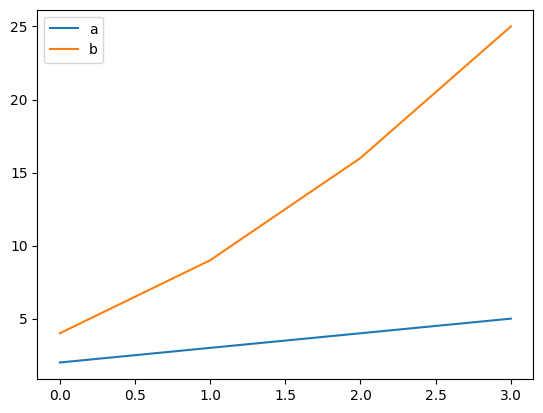

In [4]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})
print(df)

df.plot()
plt.show()

Para dibujar esta gráfica, hemos importado tanto pandas como pyplot desde las librerías matplotlib. Una convención popular es usar plt como el alias para la librería pyplot. 

El método `plot()` de pandas prepara la imagen con los datos, mientras que la función `show()` de pyplot presenta la imagen al usuario.

Por defecto, el método `plot()` crea una gráfica en donde todas las columnas numéricas en el DataFrame se trazan en los mismos ejes. Los índices están en el eje X y los valores de las columnas están en el eje Y.

Si es necesario, también puedes trazar solamente una columna individual.

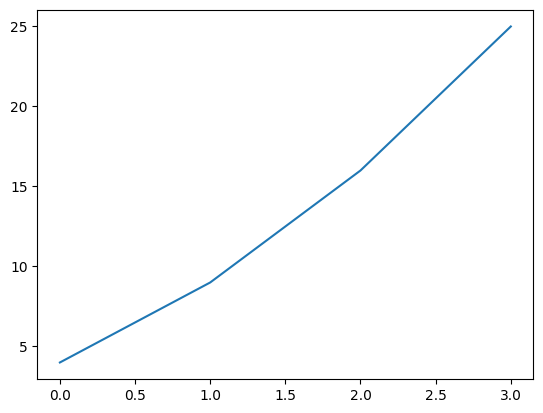

In [5]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df['b'].plot()
plt.show()

En algunos entornos de desarrollo, como Jupyter notebooks, no necesitas usar `plt.show()` para mostrar tu gráfica. Pero es una buena práctica incluir siempre `plt.show()` para que tus gráficas se muestren en cualquier entorno en el que otra persona pueda ejecutar tu código.

Otra opción que podrías necesitar es escribir código que almacena nuestras gráficas como archivos de imagen. Por ejemplo, podemos almacenar la gráfica anterior en formato PNG usando la función `savefig()` de `matplotlib`:

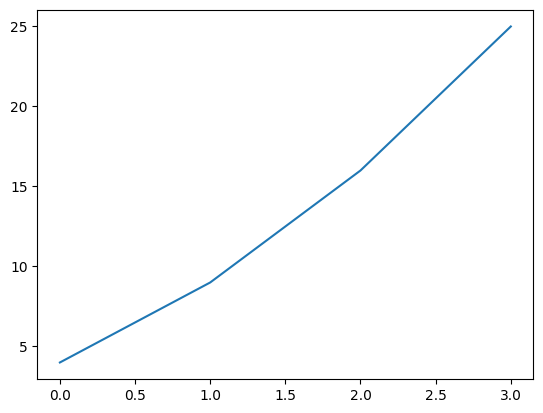

In [6]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df['b'].plot()
plt.savefig('myplot.png')

Si ejecutas este código en tu máquina local, debes tener un archivo PNG llamado myplot.png en cualquier directorio en el que se encuentre tu script de Python o Jupyter notebook. Python sabe en qué formato guardar el archivo según la extensión en tu entrada de string para `savefig()`.

### Personalización de gráficas con parámetros `plot()`

Tal vez notaste que los gráficos que hemos hecho hasta ahora son bastante básicos y no cumplen con las buenas prácticas que aprendiste anteriormente en este capítulo. Bueno, `plot()` tiene muchos parámetros adicionales que podemos usar para arreglar esto.

**Títulos**

Los títulos de los gráficos se pasan al parámetro title= como strings:

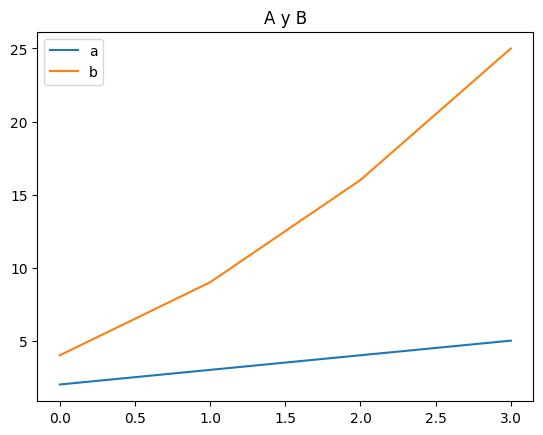

In [7]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(title='A y B')
plt.show()

¡Ahora tenemos un buen título para complementar nuestro gráfico! Aunque nos gustaría elegir algo más descriptivo que "A y B" si se tratara de datos reales, claro.

**Estilos de línea**

Nuestra gráfica no es tan mala, pero un gráfico de líneas podría no ser lo mejor aquí, ya que implica que tenemos puntos de datos a lo largo de toda la línea cuando, de hecho, sólo tenemos cuatro. Para que le resulte obvio a cualquiera que mire el gráfico, sería mejor usar un estilo de marcado distinto para los puntos de datos.

Para cambiar el estilo de marcador del gráfico, puedes usar el parámetro `style=`. Vamos a pasarle un argumento de `'o'` para que cada valor se marque como un punto.

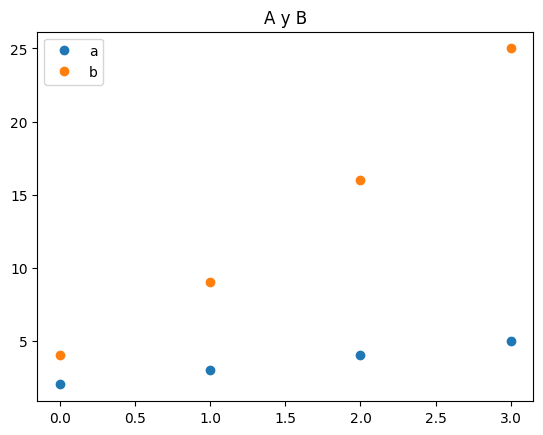

In [8]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(title='A y B', style='o')
plt.show()

También hay otros estilos de marcador; por ejemplo, `style='х'` marca cada punto con una x:

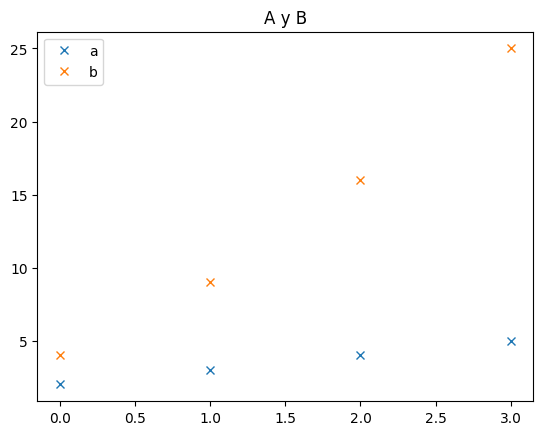

In [9]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(title='A y B', style='x')
plt.show()

Incluso se pueden combinar diferentes estilos. Por ejemplo, cuando queremos mostrar tanto líneas como puntos, podemos usar `style='o-'`:

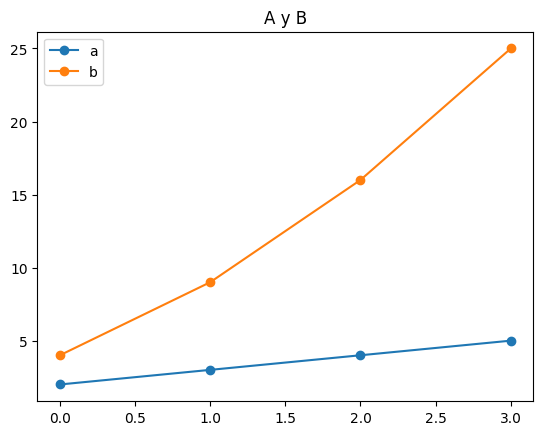

In [10]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(title='A y B', style='o-')
plt.show()

Existen muchas otras opciones de estilo de marcador (materiales en inglés), ¡así que siéntete libre de jugar con ellas y explorarlas!
https://matplotlib.org/stable/api/markers_api.html

**Ejes**

En todos los gráficos que has visto hasta ahora, el eje horizontal contiene los valores del índice DataFrame. Pero, ¿qué sucede si deseas trazar dos columnas una frente a la otra? Podemos usar los parámetros `x=` y `y=` para lograr esto:

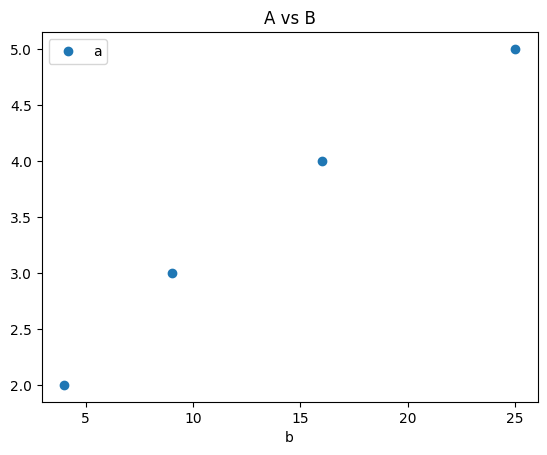

In [11]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(x='b', y='a', title='A vs B', style='o')
plt.show()

Aquí, la columna `'a'` está en el eje Y y la columna `'b'` está en el eje X. Observa que pandas ha cambiado automáticamente el nombre del eje horizontal `'b'` y la leyenda predeterminada ahora se refiere solo a la columna `'a'`. 

Para cambiar las etiquetas de los ejes, podemos usar los parámetros `xlabel=` y `ylabel=` del método `plot()`:

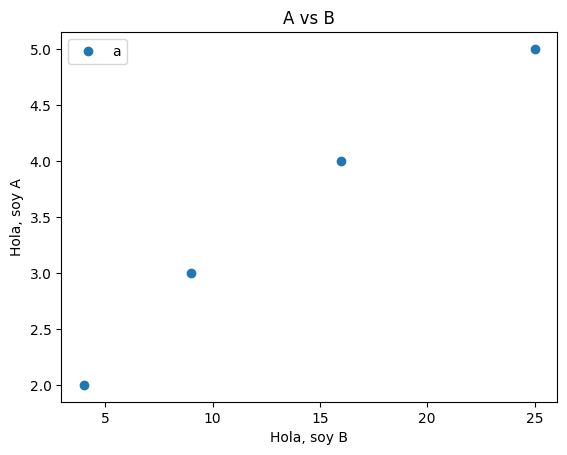

In [12]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(x='b',
        y='a',
        title='A vs B',
        style='o',
        xlabel="Hola, soy B",
        ylabel="Hola, soy A")

plt.show()

Es importante mencionar que hay una forma alternativa de configurar las etiquetas, para ambos ejes X y Y. En lugar de especificar `xlabel=` y `ylabel=` en el método `plot()`, podemos configurar las etiquetas a través de `plt.xlabel()` y `plt.ylabel()`. Así es como se hace:

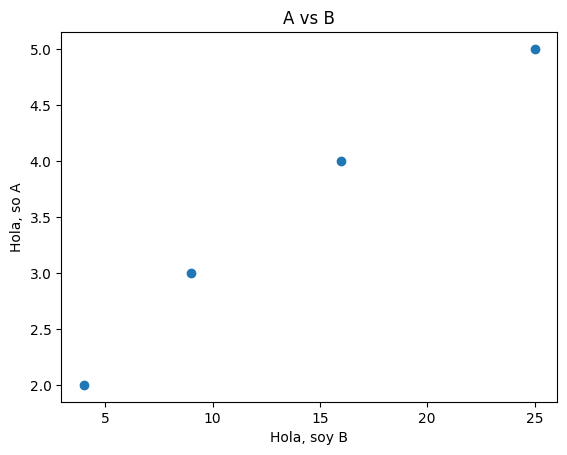

In [13]:

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(x='b',
        y='a',
        title='A vs B',
        style='o',
        legend=False)

plt.xlabel("Hola, soy B") # configurando la leyenda x
plt.ylabel("Hola, so A") # configurando la leyenda y
plt.show()

A continuación, también podemos establecer los límites de los ejes usando los parámetros `xlim=` y `ylim=`. Estos toman un número o una lista de dos números como sus argumentos. Si pasas un solo número, será el valor mínimo mostrado para el eje correspondiente. Si pasas una lista de dos números, el primer número será el valor mínimo y el segundo número será el máximo.

Ampliemos el rango del eje horizontal de 0 a 30, y establezcamos el valor mínimo del eje vertical en 0:

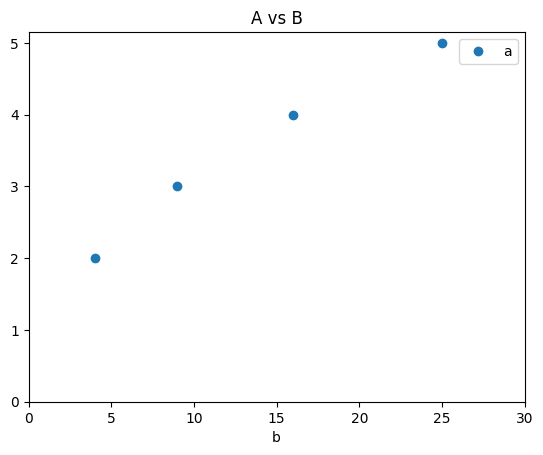

In [14]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(x='b', y='a', title='A vs B', style='o', xlim=[0, 30], ylim=0)
plt.show()

**Otras opciones de personalización**

Puedes agregar otras características a tus gráficos si crees que los harán más fáciles de leer. Agreguemos líneas de cuadrícula para ayudar a que el ojo capte qué valores estamos trazando. Para hacerlo, establece el parámetro `grid=` en `True` (de manera predeterminada, este parámetro está establecido en False):

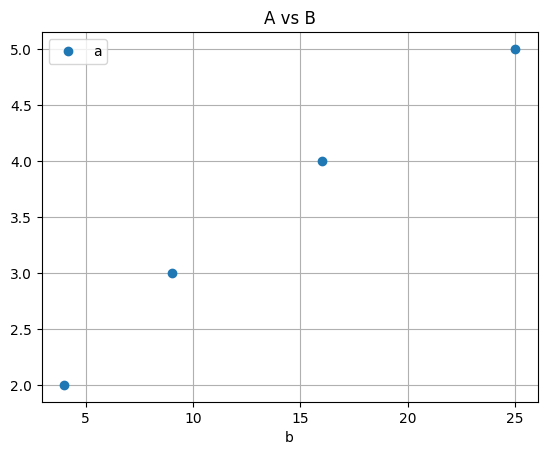

In [15]:
df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

df.plot(x='b', y='a', title='A vs B', style='o', grid=True)
plt.show()

También podemos gestionar el tamaño de nuestra gráfica con el parámetro `figsize=` (tamaño de la gráfica). El ancho y el alto en pulgadas se pasan como una lista: `figsize=[width, height]`. Comparemos dos gráficas de diferentes tamaños:

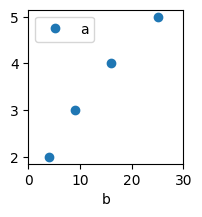

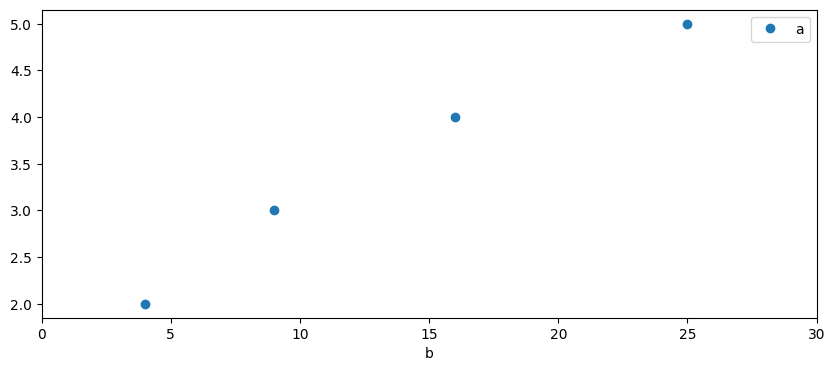

In [16]:

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25]})

# construir una gráfica pequeña
df.plot(x='b', y='a', style='o', xlim=[0, 30], figsize=[2, 2])

# construir una gráfica grande
df.plot(x='b', y='a', style='o', xlim=[0, 30], figsize=[10, 4])

plt.show()

**Repaso**

Aquí tienes un resumen de todos los métodos y funciones que hemos mencionado en esta lección:

- `plot()`: método de pandas que prepara la imagen con los datos.
- `show()`: función de la librería pyplot de Matplotlib que presenta la imagen al usuario.
- `savefig()`: función de Matplotlib que almacena la gráfica como un archivo de imagen.
- `title=`: parámetro para establecer el título del gráfico.
- `style=`: parámetro para cambiar el estilo de marcador del gráfico.
- `x=` y `y=`: parámetros para trazar dos columnas, una frente a la otra.
- `xlabel=` y `ylabel=`: parámetros para establecer las etiquetas de los ejes.
- `xlim=` y `ylim=`: parámetros para establecer los límites de los ejes.
- `grid=`: parámetro para agregar líneas de cuadrícula.
- `figsize=`: parámetro para agregar el tamaño de la gráfica.
- `legend=`: parámetro para agregar o eliminar la leyenda.

### Ejercicios
Hemos importado pandas y las librerías pyplot de Matplotlib en el precódigo proporcionado, y creamos un DataFrame llamado df. 

Tu tarea es crear un gráfico con forma de estrellas rosas utilizando los datos en df. Para tu comodidad, todos los atributos necesarios se enumeran a continuación. Sigue las instrucciones para lograr el resultado deseado. Si lo necesitas, consulta la sección de repaso para recordar los nombres de los parámetros.

Usando el método `plot()` de pandas, crea un trazo de columna `'a'` frente a la columna `'c'` del df que tenga los siguientes argumentos:

- El título "A vs C" (el uso de mayúsculas y minúsculas es importante, así que puedes copiarlo y pegarlo).
- Un estilo de marcador de estrella (puedes usar un asterisco '*' para lograrlo).
- Marcadores de color rosa fuerte (utiliza el nuevo y obvio parámetro `color=` para hacerlo, con el argumento `'hotpink'`)
- Tamaño de la gráfica de 5 por 5 pulgadas.
- Rango del eje X de 0 a 12.
- Rango del eje Y de 1 a 6.
- Eje X con la leyenda "C".
- Eje Y con la leyenda "A".

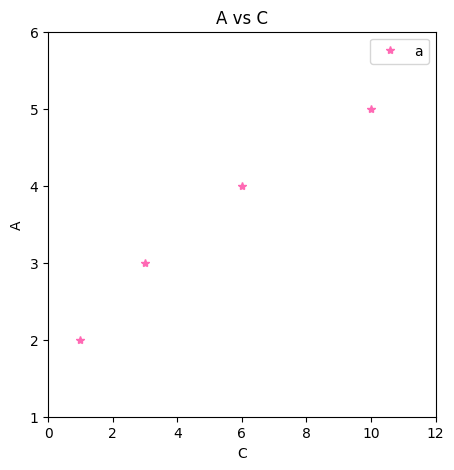

In [17]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.DataFrame({'a':[2, 3, 4, 5], 'b':[4, 9, 16, 25], 'c':[1, 3, 6, 10]})

df.plot(x='c',
        y='a',
        title='A vs C',
        style= '*',
        color = 'hotpink',
        figsize = [5, 5],
        xlim = [0, 12],
        ylim = [1,6],
        xlabel = 'C',
        ylabel= 'A'
       )

plt.show()

## Gráficos de dispersión
Una parte importante del análisis exploratorio de datos es desarrollar una comprensión de las relaciones entre las variables (es decir, columnas) en nuestros datos.

Podrías necesitar, por ejemplo, entender mejor la relación entre la altura y el peso, entre la temperatura y la venta de helados, la relación entre el nivel educativo y el salario, o la relación entre las horas de estudio y los puntajes de exámenes. Los gráficos de dispersión son una excelente manera de visualizar estas relaciones.

Un gráfico de dispersión es simplemente una gráfica en donde se traza un solo punto para cada conjunto de variables, pero los puntos no están conectados mediante líneas.

¡Mira el siguiente video y después vuelve a leer para saber más!

https://youtu.be/ZghXsmGN70E

Para ilustrar aún mejor la utilidad de los gráficos de dispersión, examinemos un conjunto de datos de alturas y pesos de 10 000 adultos en los EE.UU. Empezaremos, como de costumbre, leyendo los datos, mostrando las primeras filas y visualizando información general sobre el conjunto de datos.

In [19]:
import pandas as pd
import random

data = []
for i in range(150):
    registro = {
        'height': round(random.uniform(53.66, 79.6),2),
        'weight': round(random.uniform(63.7, 280.99),2),
        'age': random.randint(25, 50),
        'male' : random.randint(0, 1)
    }
    data.append(registro)


df = pd.DataFrame(data)
print(df.head())
print()
df.info()

   height  weight  age  male
0   59.53  269.98   40     1
1   78.00  216.56   47     1
2   56.12   87.01   46     1
3   55.28  136.86   25     1
4   79.18   89.35   35     0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   height  150 non-null    float64
 1   weight  150 non-null    float64
 2   age     150 non-null    int64  
 3   male    150 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 4.8 KB


Los datos tienen cuatro columnas y 10 000 filas, sin valores ausentes. Cada fila contiene datos recopilados para un individuo único. Las columnas son:

- `'height'`: altura de la persona, en pulgadas.
- `'weight'`: peso de la persona, en libras.
- `'age'`: edad de la persona, en años.
- `'male'`: sexo de la persona, donde 1 = masculino y 0 = femenino.

Vamos a ver una descripción numérica de los datos:

In [20]:
print(df.describe())

           height      weight         age        male
count  150.000000  150.000000  150.000000  150.000000
mean    65.845000  169.620533   37.826667    0.500000
std      7.961681   63.804036    7.401022    0.501675
min     53.880000   63.880000   25.000000    0.000000
25%     59.327500  119.615000   32.000000    0.000000
50%     64.760000  176.215000   38.000000    0.500000
75%     72.310000  220.002500   44.000000    1.000000
max     79.580000  278.660000   50.000000    1.000000


A partir del resultado de `describe()`, podemos determinar que el rango de edad de los adultos en el conjunto de datos es de 25 a 50 años. Se incluye la columna `'male'` en la salida porque es un tipo de datos numérico de Python, pero debemos recordar que es una variable categórica, así que no debemos dar mucha importancia a esa información.

Ahora que tenemos algunas estadísticas resumidas, vamos a usar la visualización para tener una mejor idea de los datos. Primero vamos a investigar la relación entre la altura y el peso.

Comenzaremos usando el comportamiento predeterminado del método plot() para hacer un gráfico de líneas, colocando la altura y el peso en los ejes X y Y, respectivamente:

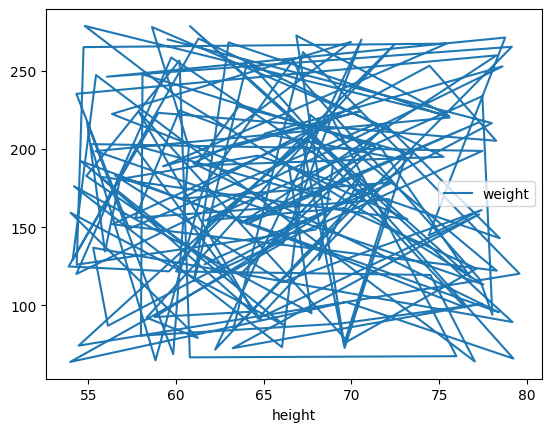

In [21]:
df.plot(x='height', y='weight')
plt.show()

¡Vaya! ¡Qué desastre! ¿Por qué nuestro gráfico se ve así?

Por defecto, el método plot() crea un gráfico de líneas pasando en orden por cada fila del DataFrame. Para cada fila se traza un punto, y este punto se conecta con el anterior utilizando una línea.

Dado que nuestro DataFrame no está ordenado por ninguna columna en particular, los puntos están por todos lados y las líneas que los conectan no tienen sentido, causando este desorden en el gráfico.

Vamos a ordenar nuestros datos por altura y graficarlos de nuevo para averiguar si podemos mejorar la gráfica:

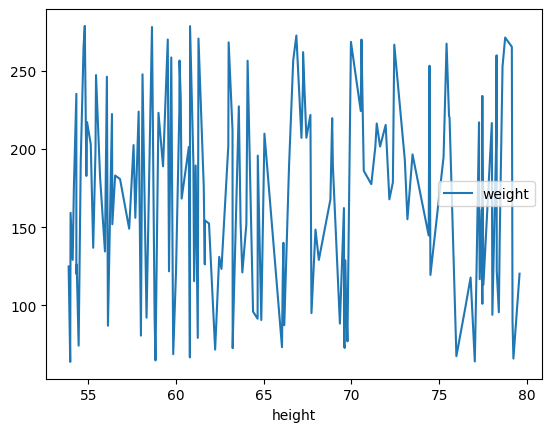

In [22]:
df.sort_values('height').plot(x='height', y='weight')
plt.show()

Eso es un progreso, pero conectar los puntos de datos con líneas no tiene caso, ya que la altura y peso de una persona no están relacionados con la altura y el peso de otra. Cada punto de datos representa una medición discreta e independiente.

Cuando decides qué tipo de gráfico usar para tus datos, es importante tomar en cuenta qué representa cada punto de datos y cómo se relaciona con el siguiente. Esto debe ser lo primero en lo que pienses cuando elijas una gráfica para tu presentación.

En este caso, es mejor usar puntos individuales para trazar datos discretos como estos. Y ahí es exactamente donde entran los gráficos de dispersión. Con un gráfico de dispersión no es necesario ordenar los datos, el diagrama se verá exactamente igual sin importar cómo se ordenen las filas en el DataFrame. Esto también resuelve la cuestión de la relación entre los puntos de datos, ya que no existe una relación visible embebida en el gráfico de dispersión.

En la lección anterior, aprendimos una manera indirecta de crear gráficos de dispersión al incluir ciertos argumentos para el parámetro style=.

Por ejemplo, podemos usar 'o' para hacer un gráfico de dispersión donde cada punto está marcado con un círculo:

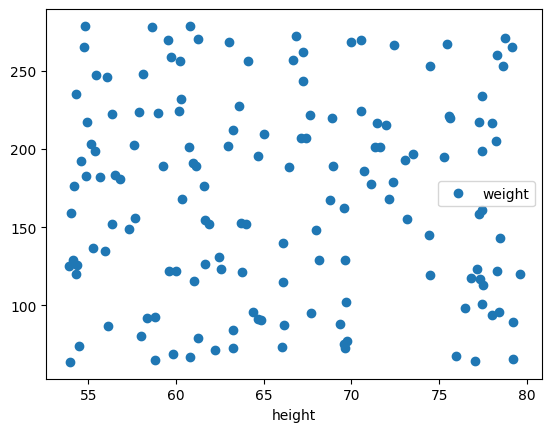

In [23]:
df.plot(x='height', y='weight', style='o')
plt.show()

Cada punto de datos ahora se traza de manera independiente, dejando en claro que existe una relación entre el peso y la altura. El gráfico de dispersión también nos permite identificar fácilmente puntos atípicos. Sin embargo, existe una manera aún mejor de crear gráficos de dispersión utilizando pandas.

Podemos crear un gráfico de dispersión directamente usando el parámetro `kind=` en `plot()`. 

Este parámetro le dice a `plot()` qué tipo de gráfico crear. En este caso, usamos el argumento `'scatter'` para crear un gráfico de dispersión.

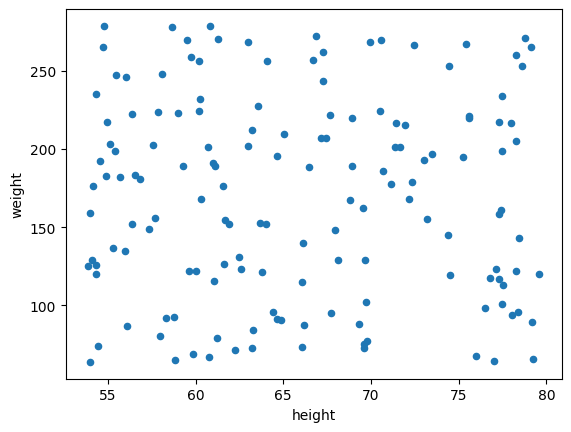

In [24]:
df.plot(x='height', y='weight', kind='scatter')
plt.show()

## Parámetro alpha
Los puntos de datos son casi idénticos en ambos gráficos. Los puntos en el segundo gráfico son ligeramente más pequeños que los del primero, pero ¿observas alguna otra diferencia entre estas dos maneras de crear un gráfico de dispersión?

Si no especificamos `kind='scatter'`, entonces el eje Y no está etiquetado de forma predeterminada y también tenemos una leyenda innecesaria. Al crear explícitamente un gráfico de dispersión, ya está bien formateado con ejes etiquetados.

Solo nos queda una última cosa de la cual hablar sobre los gráficos de dispersión. Con tantos puntos, muchos de ellos se superponen, lo que dificulta tener una buena idea de la densidad de puntos en el gráfico anterior.

Sin embargo, podemos solucionar este problema usando el parámetro `alpha=`. Este parámetro rige la transparencia de los puntos y puede aceptar cualquier valor entre 0 (completamente transparente) y 1 (nada transparente). Por defecto, se establece en 1, indicando que no hay transparencia.


## Resumen

Recapitulemos. Esto es lo que hemos visto hasta ahora:

- `sort_values()`: ordena los datos por la columna que se pasó.
- `style='o'`: crea un gráfico de dispersión marcando explícitamente cada punto de datos con un círculo.
- `kind='scatter'`: crea un gráfico de dispersión usando el método predeterminado plot.
- `alpha=` establece la transparencia de los puntos en el gráfico al valor especificado.

Ahora que ya entiendes las razones y métodos para crear gráficos de dispersión, ¡llegó el momento de ponerse manos a la obra!

## Ejercicio
Para hacer el análisis más interesante y fácil de entender, usaremos el mismo conjunto de datos de antes, pero esta vez analizaremos `height` frente a `age` en lugar de `weight`. Vas a crear un gráfico de dispersión que muestre la relación entre estas dos variables.

Los datos de altura y peso del adulto se han leído en la variable df para ti en el precódigo. Utiliza el argumento `kind='scatter'` para crear el gráfico de dispersión deseado. Da al gráfico los siguientes argumentos:

- El título “Adult heights” ("Altura de adultos" en Espanol) (el uso de mayúsculas y minúsculas es importante).
- Valor alfa de 0.36.
- Tamaño de la gráfica de 8 por 6 pulgadas.
- Eje X etiquetado “Age / years” (“Edad / anos“ en Espanol).
- Eje Y etiquetado “Height / inches” ("Altura / pulgadas" en Espanol).

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   height  150 non-null    float64
 1   weight  150 non-null    float64
 2   age     150 non-null    int64  
 3   male    150 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 4.8 KB


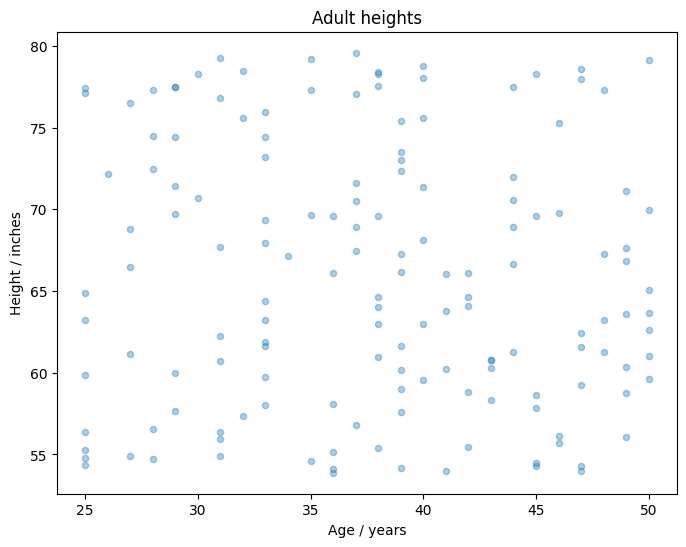

In [29]:
df.plot(x='age',
        y='height',
        kind= 'scatter',
        alpha= 0.36,
        title='Adult heights',
        xlabel= 'Age / years',
        figsize = [8, 6],
        ylabel= 'Height / inches'
       )
plt.show()

# Correlación

A menudo, el principal objeto del análisis de datos es mostrar la relación entre dos variables. Por ejemplo, podemos querer determinar cómo se relaciona el precio de un apartamento con su tamaño. ¿Afecta a su valor la distancia desde el centro? ¿Qué impacto tiene el año de construcción o el nivel de ruido que tiene el barrio? Los gráficos de dispersión nos ayudan a responder estas preguntas, ya que nos proporcionan una representación visual de estas relaciones.

A la tendencia de una variable a cambiar en relación con el cambio en otra variable se le llama correlación.

Los gráficos de dispersión que hicimos en la última lección muestran que la altura y el peso se correlacionan positivamente. Esto tiene sentido porque un aumento en uno generalmente significa un aumento en el otro. Un ejemplo de correlación negativa sería la altura y el tono de voz; generalmente, cuanto más alta sea una persona, menor será la frecuencia de su voz.
Coeficiente de correlación

Una cosa es mirar el gráfico, pero también necesitamos una forma numérica para describir la correlación.

Para cuantificar cómo una variable tiende a cambiar cuando la otra variable cambia, utilizamos el coeficiente de correlación de Pearson, conocida comúnmente como el coeficiente de correlación. Este coeficiente puede tomar cualquier valor entre -1 y 1.

Un valor de -1 representa una correlación lineal negativa perfecta, mientras que un valor de 1 representa una correlación lineal positiva perfecta. En general, el coeficiente de correlación funciona de este modo:

    Si uno de los valores incrementa junto con el otro, el coeficiente de correlación es positivo.
    Si uno permanece igual mientras el otro cambia, el coeficiente es 0.
    Si uno se reduce mientras el otro incrementa, el coeficiente es negativo.

Cuanto más cerca esté el coeficiente de -1 o 1, más fuerte será la correlación. Por otro lado, un valor de 0 puede significar que no hay correlación o que hay una conexión no lineal compleja que el coeficiente no puede reflejar.

## Calcular el coeficiente de correlación

En pandas, puedes calcular el coeficiente de correlación de Pearson usando el método `corr()`. Para hacerlo, aplícalo a la columna con la primera variable, y pasa la columna con la segunda variable como un parámetro. No importa el orden de las variables. Por ejemplo:

In [30]:
print(df['height'].corr(df['weight']))

-0.0228236099135336


Con un coeficiente de alrededor de 0.9, la altura y el peso tienen una fuerte correlación positiva en este conjunto de datos. Esto coincide con nuestro "sentido común" de que las personas más altas tienden a pesar más. Por supuesto, hay variación en esta tendencia, por lo que no esperaríamos un coeficiente de correlación positivo perfecto de 1.

Puede ser tentador hacer una declaración como "la altura de una persona determina su peso". Sin embargo, por sí sola, la correlación no puede decirnos nada sobre causa y efecto; solo sabemos que los dos factores están correlacionados. Para probar (o refutar) la causa y efecto, necesitaríamos realizar experimentos controlados. Recuerda, correlación no implica causalidad.

Por ahora, vamos a practicar el cálculo de coeficientes de correlación para otros pares de variables en nuestro conjunto de datos.

## Ejercicios

### Ejercicio 1

¿Recuerdas el gráfico de dispersión que hiciste en la última lección para las columnas  `'height'` y `'age'`? Ahora vas a calcular el coeficiente de correlación de Pearson para aquellas columnas y asigna el resultado a una variable llamada `ah_corr`. Después muéstralo. ¿El resultado se alinea con el gráfico de dispersión?

In [33]:
ah_corr= df['age'].corr(df['height'])
print(ah_corr)

-0.07527311288483564


### Ejercicio 2

Intenta llamar al método `corr()` en todo el DataFrame. Para ello, sigue el mismo proceso que antes, pero no pases ninguna variable al DataFrame df o al método `corr()`. ¿Qué pasa? Imprime el resultado.

In [34]:
df.corr()

,height,weight,age,male
height,1.000000,-0.022824,-0.075273,0.032119
weight,-0.022824,1.000000,0.126454,-0.011301
age,-0.075273,0.126454,1.000000,-0.021691
male,0.032119,-0.011301,-0.021691,1.000000


## Crear matrices de dispersión

En la lección anterior, encontramos una fuerte correlación entre la altura y el peso, pero en la vida real, las cosas rara vez son tan simples. Si nos interesa explorar los factores que contribuyen al peso de las personas, hay mucho más que considerar además de la altura. Por ejemplo, también podríamos querer saber cómo la edad y el sexo se correlacionan con el peso, o cómo se correlacionan entre sí.

Desafortunadamente, es imposible trazar los cuatro parámetros en el mismo gráfico de forma coherente. Sin embargo, podemos crear gráficos de dispersión para cada posible par de parámetros: altura y peso, altura y edad, peso y sexo, etcétera. Este conjunto de gráficos por pares se denomina matriz de dispersión.

En pandas, podemos construir matrices de dispersión usando la función `plotting.scatter_matrix()`: 

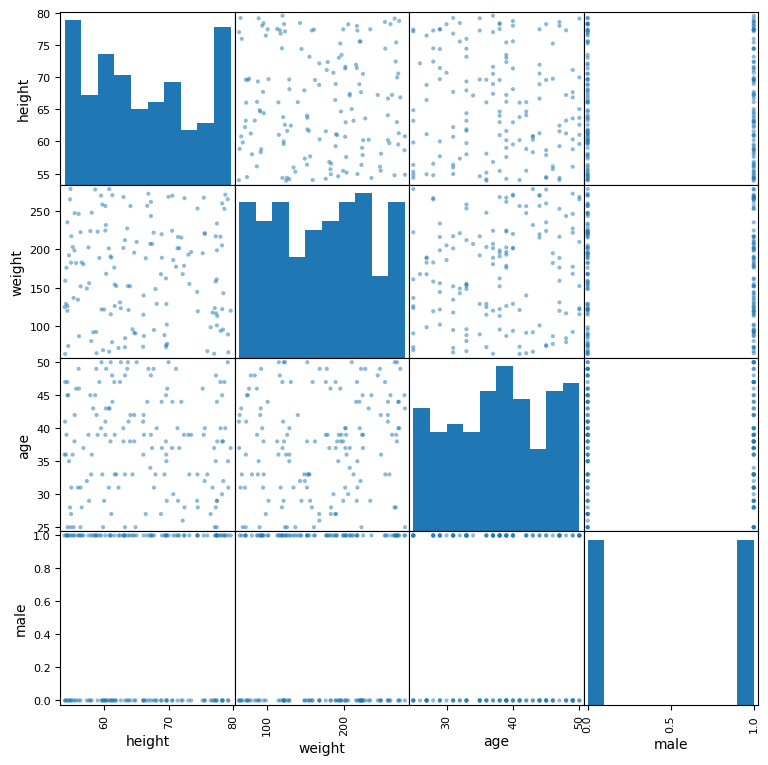

In [35]:
pd.plotting.scatter_matrix(df, figsize=(9, 9))
plt.show()

Cada celda de esta cuadrícula de 4x4 muestra la relación entre un par de columnas. Vamos a descomponerla. Mostraremos cada gráfico debajo de la explicación, y puedes encontrarla nuevamente en la matriz, para que tú la ubiques.

* Las celdas diagonales no muestran las relaciones entre variables. En su lugar, existen los histogramas que muestran la distribución de valores para cada variable individual. Por ejemplo, examina la primera imagen en la parte superior. Ahí podemos ver que los adultos suelen medir entre 64 y 68 pulgadas de altura. En el último capítulo estudiaremos los histogramas con más detalle.
* Las celdas que están justo debajo y al lado del histograma de altura muestran la conexión entre altura y peso. Ambos gráficos de dispersión de altura-peso contienen información idéntica, pero los ejes simplemente están invertidos. Vimos este gráfico de dispersión en la última lección, y determinamos que es indicativo de una fuerte correlación positiva (un coeficiente de correlación de aproximadamente 0.9).
* Los gráficos de dispersión para la relación edad-altura muestran una amplia dispersión de puntos sin una relación claramente discernible, como pudiste observar cuando creaste este gráfico de dispersión y calculaste el coeficiente de relación (alrededor 0.01) en las lecciones anteriores.
* Los gráficos de dispersión edad-peso también tienen una amplia dispersión de pesos para cada edad, pero parece que puede haber una tendencia ligeramente positiva para los gráficos de dispersión edad-altura.
* La última fila (y la última columna) de los gráficos de dispersión muestra la relación entre el género y las otras variables, en donde un valor de 1 significa que la persona es del género masculino y 0, del femenino. Estas gráficas muestran una correlación positiva en las relaciones género-altura y género-peso, pero no en género-edad.

Con una sola línea de código creamos una matriz de dispersión que nos permitió hacer muchas deducciones sobre las relaciones entre las variables en nuestro conjunto de datos. ¿No crees que sería genial si pudiéramos cuantificar todas estas relaciones también?

## Matrices de correlación
En un ejercicio de la última lección, llamaste al método corr() en nuestro DataFrame y obtuviste este resultado:

              height    weight       age      male
    height  1.000000  0.916526  0.010042  0.760690
    weight  0.916526  1.000000  0.228538  0.785218
    age     0.010042  0.228538  1.000000  0.004750
    male    0.760690  0.785218  0.004750  1.000000

La tabla devuelta se denomina matriz de correlación. Esta matriz contiene los coeficientes de correlación para cada par de columnas numéricas en el DataFrame.

Los coeficientes en la diagonal de la parte superior-izquierda a la inferior-derecha siempre son igual a 1, ya que cualquier variable se correlaciona perfectamente consigo misma. Los elementos diagonales arriba (y debajo) de la diagonal principal contienen los coeficientes para cada par de columnas. En este caso, hay 6 coeficientes de correlación únicos para los posibles pares de las variables comparadas.

Construir una matriz de correlación es una forma mucho más rápida de obtener todos los coeficientes de correlación que llamar individualmente a corr() para cada par de columnas. En este caso, solo hay 6 pares, ¡pero imagina si tuviéramos docenas de columnas numéricas!

### Ejercicio
Obtén los coeficientes de correlación para la columna `'male'` con cada una de las otras tres columnas. Pero en lugar de llamar `corr()` en la columna `'male'` tres veces por separado, crea una matriz de correlación y extrae los tres coeficientes que deseas. El resultado debería ser un objeto Series con tres elementos, uno para cada coeficiente.

Asigna la matriz de correlación a una variable llamada corr_mat y asigna el Series de coeficientes a una variable llamada male_corr. Luego, muestra male_corr.

Usa loc[] con 'male' como el primer argumento, y una lista de los otros datos como el segundo argumento para extraer aquellos valores para la variable male_corr.

In [46]:
corr_mat= df.corr()
male_corr= corr_mat.loc['male'][0:3]
print(male_corr)

height    0.032119
weight   -0.011301
age      -0.021691
Name: male, dtype: float64


Gráficos de líneas

¿Recuerdas cuando usamos el método plot() sin especificar un argumento para el parámetro kind=? Eso nos dio un gráfico de líneas donde cada punto de datos está conectado de forma secuencial por una línea.

Sin embargo, un gráfico de líneas no es apropiado para estos datos porque estos gráficos implican una relación entre puntos de datos consecutivos.

En cambio, los gráficos de líneas son excelentes cuando tienes datos que se conectan cronológicamente y cada punto de tiempo de los datos tiene alguna dependencia con el punto anterior. Cosas como datos de temperatura, datos de tráfico y datos del mercado de valores son buenos candidatos para los gráficos de líneas.

En esta lección, vamos a trabajar con datos del mercado de valores de Starbucks (SBUX) desde 2015 hasta 2019. Obtuvimos este conjunto de datos de Yahoo Finanzas y lo modificamos para que contuviera solo un subconjuto de las columnas disponibles.

             date       open      close    volume
    0  2015-01-02  41.064999  40.720001   6886000
    1  2015-01-05  40.070000  39.939999  11623800
    2  2015-01-06  40.169998  39.615002   7664400
    3  2015-01-07  39.875000  40.590000   9732600
    4  2015-01-08  41.165001  41.244999  13170600

    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 1258 entries, 0 to 1257
    Data columns (total 4 columns):
     #   Column  Non-Null Count  Dtype  
    ---  ------  --------------  -----  
     0   date    1258 non-null   object 
     1   open    1258 non-null   float64
     2   close   1258 non-null   float64
     3   volume  1258 non-null   int64  
    dtypes: float64(2), int64(1), object(1)
    memory usage: 39.4+ KB

Hay cuatro columnas en el conjunto de datos:

- `'date'`: fecha en la que se registraron los datos.
- `'open'`: precio de una acción en USD en la apertura del mercado, es decir, el primer precio del día.
- `'close'`: precio de una acción en USD al cierre del mercado, es decir, el último precio del día.
- `'volume'`: número total de acciones cotizadas.

Por ejemplo, la primera fila nos dice que el 2 de enero de 2015, el precio de apertura de las acciones de Starbucks fue de $41.06, el precio de cierre fue de $40.72 y ese día se negociaron 6 866 000 acciones. Cada fila representa un día de negociación cuando el mercado estaba abierto, lo que excluye los fines de semana y ciertos días festivos.

Del resultado de info(), también vemos que 'date' tiene un tipo de datos string, las otras columnas son numéricas y no faltan valores. Para nuestros propósitos, está bien representar las fechas como strings, pero más adelante en el sprint, aprenderás sobre tipos de datos especiales para fechas y horarios que te facilitarán extraer información y realizar cálculos con ellos.

Para datos temporales como este, es razonable suponer que el precio de un día tiene alguna relación con el precio del día anterior. Así que avancemos y hagamos un gráfico de líneas para visualizar el precio de apertura de las acciones de Starbucks durante el ciclo de vida del conjunto de datos:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/sbux.csv')
    
    df.plot(x='date', y='open')
    plt.show()

Todo lo que teníamos que hacer para trazar un gráfico de líneas era llamar a plot() en nuestro DataFrame sin un argumento kind= y especificar qué columnas queremos trazar en los ejes X y Y, tal como ya lo hemos hecho con nuestros otros gráficos. No tienes que especificar el argumento kind= como "line", puesto que ya es un valor predeterminado.

Ahora tenemos una gran representación del precio de apertura histórico de las acciones de Starbucks. Parece que el precio se dispara bastante rápido más adelante en el gráfico. ¿Alrededor de qué fecha ocurrió eso? Es difícil saberlo a partir de este gráfico porque las etiquetas de marca del eje X se superponen entre sí.

Además, para corregir la superposición de etiquetas de marca, ¿qué otras mejoras podríamos hacerle a este gráfico?

Ahora, vamos a usar nuestras habilidades para mejorar esta gráfica como corresponde.

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/sbux.csv')
    
    df.plot(x='date',
            y='open',
            legend=False,
            title='Starbucks market open',
            xlabel='Date',
            ylabel='Share price / USD',
            rot=45)
    
    plt.show()

A estas alturas, todos los parámetros que usamos para este gráfico te deben resultar familiares, a excepción del último: rot=. Este argumento rota las etiquetas de marca del eje X tantos grados como lo establezcas. Lo usamos para que nuestras etiquetas de marca no se superpongan unas a otras, y ahora se presentan en ángulos de 45º del eje X.

¡Ahora es tu turno de crear algunos gráficos de líneas profesionales

### Ejercicios
Crea un gráfico de líneas para el volumen comercial del conjunto de datos de acciones de Starbucks. Haz que tu gráfico se adhiera a lo siguiente:

1. Titulado "Historic SBUX volume" ("Volumen histórico de SBUX”) (la distinción entre mayúsculas y minúsculas es importante).
2. Eje X con la leyenda “Date” ("Fecha").
3. Eje Y con la leyenda “Volume” ("Volumen").
4. Leyendas de marca del eje X rotadas 50 grados.
5. El límite del eje Y de 1 millón a 70 millones (puedes usar 1e6 y 7e7 como los límites inferior y superior, respectivamente, para evitar escribir tantos ceros. 1e6 significa "1 por 10 a la sexta potencia", es decir, 1 000 000, y 7e7 significa "7 por 10 a la séptima potencia", es decir, 70 000 000).
6. Sin leyenda.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
df = pd.read_csv('/datasets/sbux.csv')
# escribe tu código aquí
df.plot(title= 'Historic SBUX volume',
        x= 'date',
        y= 'volume',
        xlabel='Date',
        ylabel= 'Volume',
        ylim= [1e6, 7e7],
        legend = False,
        rot= 45
       )
plt.show()

### Ejercicio 2

Crea un gráfico de líneas que incluya tanto el precio de apertura como el de cierre. Para hacer esto, puedes pasar la lista de nombres de columna, cols, proporcionada en el precódigo como tu argumento para y=. Dado que tendrás dos variables diferentes en el mismo gráfico, asegúrate de incluir una leyenda esta vez. Haz que tu gráfico también cumpla con lo siguiente:

1. Titulado “Historic SBUX price” ("Precio histórico de SBUX") (la distinción entre mayúsculas y minúsculas es importante).
2. Eje X con la leyenda “Date” ("Fecha").
3. Eje Y con la leyenda “Share price / USD” ("Precio de la acción / USD"). Deja un espacio antes y después de la /, por claridad y para evitar errores.
4. Leyendas de marca del eje X rotadas 50 grados.

No olvides incluir plt.show().

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('/datasets/sbux.csv')
cols = ['open', 'close']

# escribe tu código aquí
df.plot(x='date', 
        y= cols,
        title= 'Historic SBUX price',
        xlabel= 'Date',
        ylabel= 'Share price / USD',
        rot = 50,
        legend=True
        
       )

### Gráficos de barras
Hasta ahora hemos estado aprendiendo cómo visualizar relaciones entre variables numéricas en nuestros datos, pero ¿qué pasa con las variables categóricas? La mayoría de los conjuntos de datos con los que trabajarás tienen una combinación de datos numéricos y categóricos.

Los gráficos de barras son una gran herramienta para comparar categorías definidas por un valor numérico.

Así que, en esta lección, haremos gráficos de barras para visualizar datos tomados de la Oficina del Censo de los Estados Unidos sobre niveles históricos de población en California, Oregón y Washington. Los gráficos de barras son una excelente opción aquí porque nos permitirán comparar propiedades numéricas (población) entre categorías (estados).

Comencemos mostrando información general sobre el conjunto de datos:

    import pandas as pd
    
    df = pd.read_csv('/datasets/west_coast_pop.csv')
    df.info()
    
    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 10 entries, 0 to 9
    Data columns (total 4 columns):
     #   Column  Non-Null Count  Dtype  
    ---  ------  --------------  -----  
     0   year    10 non-null     int64  
     1   ca_pop  10 non-null     float64
     2   or_pop  10 non-null     float64
     3   wa_pop  10 non-null     float64
    dtypes: float64(3), int64(1)
    memory usage: 448.0 bytes

¡Solo 10 filas! También podemos mostrar todo el DataFrame, entonces:

    import pandas as pd
    
    df = pd.read_csv('/datasets/west_coast_pop.csv')
    print(df)
    
       year  ca_pop  or_pop  wa_pop
    0  1920   3.554   0.788   1.373
    1  1930   5.711   0.956   1.568
    2  1940   6.950   1.086   1.740
    3  1950  10.680   1.532   2.387
    4  1960  15.870   1.772   2.855
    5  1970  19.970   2.092   3.413
    6  1980  24.290   2.668   4.236
    7  1990  29.950   2.859   4.901
    8  2000  33.630   3.342   5.811
    9  2010  37.270   3.856   6.746

Tenemos datos de población de California, Oregón y Washington, tomados cada 10 años desde 1920 hasta 2010, en unidades de millones de personas.

Comparemos la población de cada estado por año. Para visualizar estos datos en un gráfico de barras, llamamos al método `plot()` en el DataFrame y especificamos `kind='bar'` como un argumento. Pero necesitamos especificar que queremos la columna `'year'` en el eje X, de lo contrario, el gráfico no tendrá mucho sentido:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/west_coast_pop.csv')
    
    df.plot(x='year', kind='bar')
    plt.show()

Tal como se esperaba: un conjunto de tres barras, una para cada estado, para cada año en el conjunto de datos.

Si no especificas ninguna columna para el parámetro `y=`, pandas creará automáticamente una barra para cada columna en el DataFrame que no esté en el eje X; en este caso, una barra para cada población del estado.

El gráfico de barras facilita sacar ciertas conclusiones sobre los datos. Por ejemplo, podemos ver que la población de California es consistentemente mucho mayor que la de otros estados. También vemos que la población ha crecido constantemente en todos los estados.

Sin embargo, si queremos presentar estos datos a otras personas, necesitamos que se vean más profesionales:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/west_coast_pop.csv')
    
    df.plot(x='year',
            kind='bar',
            title='West coast USA population growth',
            xlabel='Year',
            ylabel='Population (millions)')
    
    plt.legend(['CA', 'OR', 'WA'])
    plt.show()

¡Mucho mejor!

Para mejorar nuestra gráfica, usamos una nueva función de Matplotlib llamada `legend()`. Esta función nos permite especificar manualmente las etiquetas de leyenda pasando una lista de nombres de etiquetas en lugar del comportamiento predeterminado de usar los nombres de columna del DataFrame.

La audiencia a la que presentamos esta gráfica probablemente no esté familiarizada con los aspectos técnicos de nuestro conjunto de datos, por lo que nombres como `'ca_pop'` podrían no tener sentido para dicha audiencia. Es mucho mejor usar etiquetas conocidas como CA, OR y WA.

Observa que el orden de las etiquetas de la leyenda en la lista corresponderá al orden de las columnas en el DataFrame, por lo que es importante ordenar las etiquetas correctamente. Además, `plt.legend()` tiene que venir después de que llamemos a `plot()` en nuestro DataFrame.

Ahora es el momento de explorar más este conjunto de datos en las tareas.

### Ejercicios
La población de California es mucho mayor que la de Oregón y Washington, por lo que es difícil hacerse una idea de los datos de esos dos estados a partir del gráfico que hicimos. Crea un gráfico de barras que muestre solo las poblaciones de Oregón y Washington para cada año en el conjunto de datos. Hazlo llamando a plot() en df con argumentos que le den a tu gráfica las siguientes propiedades:

1. Incluye solo datos para Oregón y Washington especificando nuestro eje Y, tal como hicimos en la lección anterior.
2. Título: “Pacific Northwest population growth” (“Crecimiento de la población del noroeste del Pacífico“). La distinción entre mayúsculas y minúsculas es importante.
3. El eje X etiquetado: “Year” ("Año").
4. El eje Y etiquetado: “Population (millions)” ("Población (millones)").
5. Leyenda con etiquetas "OR" y "WA" para las poblaciones de Oregón y Washington, respectivamente.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('/datasets/west_coast_pop.csv')

# escribe tu código aquí
 

## Histogramas

Un histograma es un gráfico que muestra la frecuencia con la que aparecen diferentes valores para una variable en tu conjunto de datos. Aunque puede parecerse a los gráficos de barras, existen algunas diferencias clave entre los dos tipos:

* Los gráficos de barras se utilizan para comparar valores de variables discretas; los histogramas se utilizan para trazar distribuciones de variables numéricas continuas.
* El orden de las barras en los gráficos de barras puede modificarse para efectos de estilo o de comunicación. Sin embargo, el orden de las barras en los histogramas no puede cambiarse.

En un histograma, el eje X representa la variable y su rango de valores. El eje Y representa la frecuencia de ocurrencia para cada valor. Y es por ello que no tiene sentido cambiar el orden de las barras.

A continuación te mostramos un ejemplo:

Este histograma representa una variable que toma valores en el rango de 1 a 9, siendo los valores alrededor de 4 y 7 los más frecuentes.

Debido a que la variable puede tomar cualquier valor en el rango, contar cada valor único y graficar las frecuencias no es útil. En su lugar, un histograma parte el rango de valores en secciones llamadas contenedores. En la gráfica anterior, uno de los contenedores está resaltado para ilustrar los tamaños de los contenedores.

Cada contenedor tiene el mismo ancho; la altura de un contenedor corresponde al número de observaciones que están dentro del rango de ese contenedor. Por lo tanto, la apariencia de un histograma depende del número de contenedores que decidamos que debe tener.

El histograma anterior tiene 25 contenedores. Veamos qué pasa si trazamos los mismos datos utilizando tan solo 10 contenedores.

Y 100 contenedores:

El gráfico con 10 contenedores no tiene suficientes detalles, y el de 100 contenedores tiene demasiados. Elegir el número correcto de contenedores puede ser más un arte que una ciencia, pero con la práctica lograrás dominarlo.

Si deseas tener una mejor idea de cómo el tamaño del contenedor afecta a un histograma, puedes usar esta herramienta interactiva para cambiar la cantidad de contenedores y ver qué sucede. ¡Pruébala a continuación!

## Trazar histogramas de DataFrames

En pandas, hay dos formas de trazar histogramas:

1. El método `hist()`.
2. El método `plot()` con el argumento `kind='hist'`.

Examinemos `hist()` primero:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    df.hist()
    
    plt.show()

Si se llama a `hist()` en un DataFrame sin ningún argumento, crea un gráfico separado para cada columna numérica. ¿Estos histogramas te parecen familiares? ¡Eran los gráficos en la diagonal de nuestras matrices de dispersión!

Ahora intentemos llamar a `plot()` en nuestro DataFrame para hacer histogramas:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    df.plot(kind='hist')
    
    plt.show()

El comportamiento predeterminado de plot() difiere considerablemente del de hist(). 

Usando plot() podemos trazar cada histograma en el mismo gráfico. Sin embargo, esto no tiene sentido para estos datos, ya que cada una de las cuatro columnas representa una cantidad física distinta. Por tanto, no es adecuado trazarlas todas a lo largo del mismo eje.

### Trazado de histogramas de columnas

A menudo, querrás explorar una variable a la vez. Podemos trazar un histograma para una sola columna usando `hist()` pasando el nombre de la columna como un argumento para el parámetro `column=`. Echemos un vistazo más de cerca a la columna `'height'` (altura):

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    df.hist(column='height')
    
    plt.show()

De manera alternativa, podríamos trazar el mismo histograma llamando hist() sólo en la columna `'height'`:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    df['height'].hist()
    
    plt.show()

Por defecto, `hist()` utiliza 10 contenedores. Sin embargo, para estos datos, 10 contenedores parecen demasiado bajos para captar el nivel de detalle que deseamos. Para resolverlo, podemos usar el parámetro `bins=` para ajustar el número de contenedores usados:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    df.hist(column='height', bins=30)
    
    plt.show()

¡Mucho mejor!

Podemos hacer el mismo histograma usando `plot()` llamándolo sólo en la columna 'height':

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    df['height'].plot(kind='hist', bins=30)
    
    plt.show()

El histograma es el mismo, pero el formato predeterminado de las gráficas difiere entre métodos. Si deseas ver un histograma para una sola variable, te recomendamos usar `plot()` porque `hist()` no es compatible con todas las palabras clave de formato que has aprendido, como `title=`, `xlabel=`, `ylabel=`.

## Comparación de histogramas para subconjuntos de datos

La altura del histograma trazado arriba muestra dos picos de valores más frecuentes. Esto podría deberse a las diferencias en la distribución de la estatura de hombres y mujeres. Para investigar esta cuestión, podemos trazar los histogramas de altura para hombres y mujeres por separado en la misma gráfica.

Todo lo que tenemos que hacer es filtrar el DataFrame por sexo, y luego llamar a plot() en la columna `'height'`. Si hacemos esto dos veces (una para cada sexo), pandas automáticamente trazará ambos en el mismo gráfico, con el segundo histograma delante del primero:

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    # esto mostrará el gráfico de hombres
    df[df['male'] == 1]['height'].plot(kind='hist', bins=30)
    
    # esto mostrará el gráfico de mujeres
    # e incluye un valor alpha para que podamos ver ambos histogramas por completo
    df[df['male'] == 0]['height'].plot(kind='hist', bins=30, alpha=0.8)
    
    plt.legend(['Male', 'Female']) # leyenda, que sigue el mismo orden trazado anteriormente
    plt.show()

Colocar ambos histogramas en el mismo gráfico hace mucho más fácil ver que la distribución de las alturas para hombres se desplaza hacia la derecha en comparación con la de las mujeres. Por ejemplo, un hombre promedio es probablemente más alto que una mujer promedio. Es por eso que el histograma combinado para el conjunto de datos completo tiene dos picos.

Observa que, en este caso, tiene sentido trazar ambos histogramas en el mismo gráfico, ya que ambos representan la misma variable: height. Sin embargo, en otros casos podría no tener sentido, y debes ser consciente de ello.

Si lo necesitas, puedes usar el índice para dividir tu histograma usando la misma lógica que para el filtro que utilizaste con la variable 'male'. Para ello, ordena la variable y reinicia los índices para que la mujer sea la primera en el DataFrame. Después, corta el DataFrame a la mitad para poder ver la mitad de abajo de los datos.

    import pandas as pd
    from matplotlib import pyplot as plt
    
    df = pd.read_csv('/datasets/height_weight.csv')
    
    df = df.sort_values('male').reset_index(drop=True)
    
    df = df[df.index < 5000]
    
    df.hist(column='height', bins=50)
    
    plt.show()


## Resumen

Los histogramas nos dan una idea de cómo se distribuyen nuestros datos. Al visualizar la distribución, podemos obtener información clave tales como los valores más frecuentes y la presencia de valores atípicos.

* Podemos usar el método `hist()` o `plot()` para hacer histogramas para nuestras cuatro columnas numéricas.
* Llamar a `hist()` en un DataFrame crea un histograma por separado para cada columna numérica.
* Llamar a `plot()` con `kind='hist'` traza un histograma para cada columna numérica , todas en el mismo gráfico.
* Llamar a cualquier método varias veces trazará también cada nuevo histograma en el mismo gráfico. Esto es útil para comparar distribuciones entre diferentes subconjuntos de datos, como la altura de hombres y mujeres.

Ahora es tu turno de practicar cómo hacer histogramas.

### Ejercicios
1. Investiga la distribución del peso para diferentes grupos de edad. Haremos esto en dos pasos. Para comenzar, divide el conjunto de datos en tres DataFrames filtrando df y asígnalos a las siguientes variables:
    1. df_20s: solo las filas donde 'age' es menor a 30.
    2. df_30s: solo las filas donde 'age' es mayor o igual a 30 y menor a 40.
    3. df_40s: solo las filas donde 'age' es mayor o igual a 40 (incluye 50 años).

Para verificar que filtraste correctamente, muestra los siguientes resultados:
1. La suma de las longitudes de los tres DataFrames (debe haber 10 000 filas en total).
2. El valor mínimo y máximo en la columna 'age' de df_20s
3. El valor mínimo y máximo en la columna 'age' de df_30s
4. El valor mínimo y máximo en la columna 'age' de df_40s

El precódigo ya contiene una plantilla para que muestres tus resultados, solo completa el código.

In [ ]:
'''
# separa df en dataframes separados según la edad
df_20s = df[# inserta el filtro aquí]
df_30s = df[(# inserta el filtro aquí) & (# inserta el filtro aquí)]
df_40s = df[# inserta el filtro aquí]

# print out the results
print("La suma de las longitudes del dataframe:", # termina esta línea con la suma)
print("Edad mínima y máxima para df_20s:", # termina esta línea con mínimo y máximo)
print("Edad mínima y máxima para df_30s:", # termina esta línea con mínimo y máximo)
print("Edad mínima y máxima para df_40s:", # termina esta línea con mínimo y máximo)
'''

import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('/datasets/height_weight.csv')

# separa df en dataframes separados según la edad
df_20s = df[df['age'] < 30]
df_30s = df.query("age >= 30 and age < 40")
df_40s = df[df['age'] >= 40]

print("La suma de las longitudes del dataframe:", (len(df_20s)+len(df_30s)+len(df_40s)))
print("Edad mínima y máxima para df_20s:", df_20s['age'].min(), df_20s['age'].max())
print("Edad mínima y máxima para df_30s:", df_30s['age'].min(), df_30s['age'].max())
print("Edad mínima y máxima para df_40s:", df_40s['age'].min(), df_40s['age'].max())

2. Y, para el segundo paso, vas a crear un histograma para cada grupo de edad, todos en la misma gráfica. Para esto, haz lo siguiente:

* Llama plot() en la columna 'weight' de df_20s
    * Establece el número de contenedores a 20.
    * Título de la gráfica “Weight / lbs” ("Peso / lbs").
    * Etiqueta el eje Y “Frequency” ("Frecuencia").
* Llama plot() en la columna 'weight' de df_30s
    * Establece el número de contenedores a 20.
    * Establece el valor de alpha a 0.6.
* Llama plot() en la columna 'weight' de df_40s
    * Establece el número de contenedores a 20.
    * Establece el valor de alpha a 0.3.

Finalmente, usa la función legend() de matplotlib para etiquetar cada histograma como "20s", "30s" y "40s", respectivamente.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('/datasets/height_weight.csv')

df_20s = df[df['age'] < 30]
df_30s = df[(df['age'] >= 30) & (df['age'] < 40)]
df_40s = df[df['age'] >= 40]

df_20s['weight'].plot(kind= 'hist',
                      bins = 20,
                      title= 'Weight / lbs',
                      ylabel= 'Frequency'
                     ) # escribe tu código aquí

df_30s['weight'].plot(kind= 'hist',
                      bins = 20,
                      alpha= 0.6
                     ) # escribe tu código aquí
df_40s['weight'].plot(kind= 'hist',
                      bins = 20,
                      alpha = 0.3
                     ) # escribe tu código aquí

plt.legend(['20s', '30s', '40s']) # escribe tu código aquí

plt.show()